# Production-Grade TransUNet Training Pipeline for Stroke Segmentation

This notebook trains and evaluates the official **Beckschen/TransUNet** 2D architecture on a dataset stored in `stroke_dataset`.

It is organized as a readable, auditable pipeline:

1. Environment and reproducibility
2. Configuration
3. Dataset discovery and validation
4. Data splitting and leakage checks
5. Augmentation and data loaders
6. Official TransUNet model construction
7. Losses and metrics
8. Training and validation
9. Checkpointing and early stopping
10. Test evaluation
11. Qualitative review and artifact export

### Expected dataset layouts

The loader automatically supports either:

```text
stroke_dataset/
├── train/
│   ├── images/
│   └── masks/
├── val/                 # or validation/
│   ├── images/
│   └── masks/
└── test/
    ├── images/
    └── masks/
```

or an unsplit dataset:

```text
stroke_dataset/
├── images/
└── masks/
```

For an unsplit dataset, this notebook creates a deterministic **70/15/15** split.

Images and masks must share the same filename stem, for example:

```text
images/case_001.png
masks/case_001.png
```

Binary masks may contain `{0, 1}` or `{0, 255}`. They are converted to class IDs `{0, 1}`.

## 1. Install dependencies

The official repository was originally documented with an older Python environment. This notebook uses a modern PyTorch workflow while importing the official TransUNet model implementation.

Restart the kernel after installation if your notebook environment requires it.

In [2]:
# Uncomment and run once in a fresh environment.
%pip install \
  torch torchvision \
  numpy pandas matplotlib pillow opencv-python-headless \
  albumentations scikit-learn scipy tqdm tensorboard ml-collections

# Clone the official implementation when it is not already available.
!test -d TransUNet || git clone --depth 1 https://github.com/Beckschen/TransUNet.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 1.0 MB/s  0:00:10m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 892.6 kB/s  0:00:11eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 981.6 kB/s  0:01:03m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 1.1 MB/s  0:00:08 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 1.1 MB/s  0:00:32m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 1.0 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 1.1 MB/s  0:00:06 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 1.1 MB/s  0:00:06 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.1 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 781.4 kB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 1.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports and environment checks

In [3]:
from __future__ import annotations

import copy
import csv
import hashlib
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from PIL import Image
from scipy.ndimage import binary_erosion, distance_transform_edt
from sklearn.model_selection import train_test_split
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13
PyTorch: 2.12.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


## 3. Central configuration

In [24]:
@dataclass(frozen=True)
class Config:
    # Paths
    dataset_root: str = "stroke_dataset"
    transunet_repo: str = "TransUNet"
    output_root: str = "outputs/transunet_stroke"
    pretrained_npz: str = "model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz"

    # Dataset
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    image_size: int = 224
    num_classes = 16
    ALLOWED_CLASS_IDS = set(range(16))  # background + stroke biomarkers
    ignore_index: int = 255
    seed: int = 42

    # Pairing / leakage controls
    image_extensions: Tuple[str, ...] = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
    mask_extensions: Tuple[str, ...] = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
    # Optional: set a delimiter to infer patient ID from a filename.
    # Example "patient001_slice003" with delimiter "_slice" -> "patient001".
    patient_id_delimiter: Optional[str] = None

    # Official TransUNet architecture
    vit_name: str = "R50-ViT-B_16"
    vit_patch_size: int = 16
    n_skip: int = 3
    use_pretrained: bool = True

    # Training
    epochs: int = 100
    batch_size: int = 8
    num_workers: int = 4
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    warmup_epochs: int = 5
    early_stopping_patience: int = 15
    gradient_clip_norm: float = 1.0
    amp: bool = True

    # Loss
    ce_weight: float = 0.5
    dice_weight: float = 0.5
    foreground_dice_weight: float = 1.0

    # Runtime
    deterministic: bool = True
    pin_memory: bool = True
    persistent_workers: bool = True

CFG = Config()

assert math.isclose(CFG.train_ratio + CFG.val_ratio + CFG.test_ratio, 1.0)
assert CFG.num_classes >= 2, "This notebook uses multiclass logits: background + foreground class(es)."

DATASET_ROOT = Path(CFG.dataset_root).resolve()
REPO_ROOT = Path(CFG.transunet_repo).resolve()
OUTPUT_ROOT = Path(CFG.output_root).resolve()
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
LOG_DIR = OUTPUT_ROOT / "logs"
PREDICTION_DIR = OUTPUT_ROOT / "predictions"

for directory in (OUTPUT_ROOT, CHECKPOINT_DIR, LOG_DIR, PREDICTION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

with (OUTPUT_ROOT / "config.json").open("w") as f:
    json.dump(asdict(CFG), f, indent=2)

print(json.dumps(asdict(CFG), indent=2))

{
  "dataset_root": "stroke_dataset",
  "transunet_repo": "TransUNet",
  "output_root": "outputs/transunet_stroke",
  "pretrained_npz": "model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz",
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "image_size": 224,
  "ignore_index": 255,
  "seed": 42,
  "image_extensions": [
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
    ".bmp"
  ],
  "mask_extensions": [
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
    ".bmp"
  ],
  "patient_id_delimiter": null,
  "vit_name": "R50-ViT-B_16",
  "vit_patch_size": 16,
  "n_skip": 3,
  "use_pretrained": true,
  "epochs": 100,
  "batch_size": 8,
  "num_workers": 4,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "warmup_epochs": 5,
  "early_stopping_patience": 15,
  "gradient_clip_norm": 1.0,
  "amp": true,
  "ce_weight": 0.5,
  "dice_weight": 0.5,
  "foreground_dice_weight": 1.0,
  "deterministic": true,
  "pin_memory": true,
  "persistent_workers": true

## 4. Reproducibility and device setup

In [5]:
def seed_everything(seed: int, deterministic: bool = True) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except TypeError:
            torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False

seed_everything(CFG.seed, CFG.deterministic)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 5. Make the official TransUNet repository importable

The notebook imports the official `VisionTransformer` and configuration registry directly from:

```python
networks.vit_seg_modeling
```

In [6]:
if not REPO_ROOT.exists():
    raise FileNotFoundError(
        f"Official TransUNet repository not found at {REPO_ROOT}.\n"
        "Clone it by running:\n"
        "git clone --depth 1 https://github.com/Beckschen/TransUNet.git"
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from networks.vit_seg_modeling import VisionTransformer as ViT_seg
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg

print("Official TransUNet import succeeded.")
print("Available configurations:", sorted(CONFIGS_ViT_seg.keys()))

Official TransUNet import succeeded.
Available configurations: ['R50-ViT-B_16', 'R50-ViT-L_16', 'ViT-B_16', 'ViT-B_32', 'ViT-H_14', 'ViT-L_16', 'ViT-L_32', 'testing']


## 6. Dataset discovery and image-mask pairing

In [8]:
@dataclass(frozen=True)
class Sample:
    sample_id: str
    image_path: str
    mask_path: str
    patient_id: str


def infer_patient_id(stem: str, delimiter: Optional[str]) -> str:
    if delimiter and delimiter in stem:
        return stem.split(delimiter, 1)[0]
    return stem


def indexed_files(folder: Path, extensions: Sequence[str]) -> Dict[str, Path]:
    if not folder.exists():
        raise FileNotFoundError(f"Missing folder: {folder}")

    extensions = {e.lower() for e in extensions}
    files = [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in extensions]
    index: Dict[str, Path] = {}

    for path in files:
        stem = path.stem
        if stem in index:
            raise ValueError(
                f"Duplicate filename stem '{stem}' in {folder}:\n"
                f"  {index[stem]}\n  {path}\n"
                "Use unique stems or customize the pairing logic."
            )
        index[stem] = path

    if not index:
        raise RuntimeError(f"No supported files found in {folder}")
    return index


def pair_folder(image_dir: Path, mask_dir: Path) -> List[Sample]:
    images = indexed_files(image_dir, CFG.image_extensions)
    masks = indexed_files(mask_dir, CFG.mask_extensions)

    missing_masks = sorted(set(images) - set(masks))
    missing_images = sorted(set(masks) - set(images))

    if missing_masks or missing_images:
        raise ValueError(
            "Image-mask pairing failed.\n"
            f"Missing masks for {len(missing_masks)} images: {missing_masks[:10]}\n"
            f"Missing images for {len(missing_images)} masks: {missing_images[:10]}"
        )

    samples = []
    for stem in sorted(images):
        samples.append(
            Sample(
                sample_id=stem,
                image_path=str(images[stem]),
                mask_path=str(masks[stem]),
                patient_id=infer_patient_id(stem, CFG.patient_id_delimiter),
            )
        )
    return samples


def locate_split_dir(root: Path, candidates: Sequence[str]) -> Optional[Path]:
    for name in candidates:
        candidate = root / name
        if candidate.exists():
            return candidate
    return None


def discover_dataset(root: Path) -> Dict[str, List[Sample]]:
    train_dir = locate_split_dir(root, ("train", "training"))
    val_dir = locate_split_dir(root, ("val", "validation", "valid"))
    test_dir = locate_split_dir(root, ("test", "testing"))

    if train_dir and val_dir and test_dir:
        return {
            "train": pair_folder(train_dir / "images", train_dir / "masks"),
            "val": pair_folder(val_dir / "images", val_dir / "masks"),
            "test": pair_folder(test_dir / "images", test_dir / "masks"),
        }

    image_dir = root / "images"
    mask_dir = root / "masks"
    if image_dir.exists() and mask_dir.exists():
        return {"all": pair_folder(image_dir, mask_dir)}

    raise FileNotFoundError(
        f"Could not recognize dataset layout under {root}.\n"
        "Expected split folders containing images/ and masks/, "
        "or top-level images/ and masks/."
    )


raw_splits = discover_dataset(DATASET_ROOT)
{k: len(v) for k, v in raw_splits.items()}

{'all': 941}

## 7. Deterministic 70/15/15 split

When patient IDs are available, splitting is done by patient to prevent slices from the same patient appearing in different partitions. Otherwise each image is treated as one independent case.

In [9]:
def split_unsplit_samples(samples: List[Sample]) -> Dict[str, List[Sample]]:
    groups: Dict[str, List[Sample]] = {}
    for sample in samples:
        groups.setdefault(sample.patient_id, []).append(sample)

    group_ids = sorted(groups)
    if len(group_ids) < 3:
        raise ValueError("At least three independent patients/cases are required for train/val/test splits.")

    train_groups, temp_groups = train_test_split(
        group_ids,
        test_size=CFG.val_ratio + CFG.test_ratio,
        random_state=CFG.seed,
        shuffle=True,
    )

    relative_test_ratio = CFG.test_ratio / (CFG.val_ratio + CFG.test_ratio)
    val_groups, test_groups = train_test_split(
        temp_groups,
        test_size=relative_test_ratio,
        random_state=CFG.seed,
        shuffle=True,
    )

    def expand(ids: Sequence[str]) -> List[Sample]:
        return sorted(
            [sample for group_id in ids for sample in groups[group_id]],
            key=lambda x: x.sample_id,
        )

    return {
        "train": expand(train_groups),
        "val": expand(val_groups),
        "test": expand(test_groups),
    }


splits = (
    split_unsplit_samples(raw_splits["all"])
    if "all" in raw_splits
    else raw_splits
)

split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "images": len(samples),
            "patients_or_cases": len({s.patient_id for s in samples}),
            "ratio": len(samples) / sum(len(v) for v in splits.values()),
        }
        for name, samples in splits.items()
    ]
)
split_summary

,split,images,patients_or_cases,ratio
0,train,658,658,0.699256
1,val,141,141,0.149841
2,test,142,142,0.150903


## 8. Leakage, duplicates, corruption, and mask-value checks

In [18]:
import os
import hashlib
from typing import Dict, List, Optional, Set

import cv2
import numpy as np
import pandas as pd
import warnings
from tqdm.auto import tqdm


# ---------------------------------------------------------
# MULTICLASS CONFIGURATION
# ---------------------------------------------------------
# Assumption:
#   0     = background
#   1–16  = stroke biomarker classes
#
# Therefore, the model has 17 output classes in total.
#
# Change to range(16) if your dataset contains IDs 0–15.
NUM_FOREGROUND_CLASSES = 16
NUM_CLASSES = NUM_FOREGROUND_CLASSES + 1

ALLOWED_CLASS_IDS: Set[int] = set(range(NUM_CLASSES))


# ---------------------------------------------------------
# HASH FILE
# ---------------------------------------------------------
def sha256_file(
    path: str,
    chunk_size: int = 1024 * 1024,
) -> str:
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)

    return digest.hexdigest()


# ---------------------------------------------------------
# READ IMAGE
# ---------------------------------------------------------
def read_image(path: str) -> np.ndarray:
    image = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if image is None:
        raise ValueError(f"Unreadable image: {path}")

    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image


# ---------------------------------------------------------
# READ MASK
# ---------------------------------------------------------
def read_mask(path: str) -> np.ndarray:
    mask = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if mask is None:
        raise ValueError(f"Unreadable mask: {path}")

    # Some Labelbox masks may be saved as RGB even when they
    # contain grayscale integer class IDs.
    if mask.ndim == 3:
        channel_0 = mask[..., 0]
        channel_1 = mask[..., 1]
        channel_2 = mask[..., 2]

        channels_are_identical = (
            np.array_equal(channel_0, channel_1)
            and np.array_equal(channel_1, channel_2)
        )

        if not channels_are_identical:
            raise ValueError(
                f"Mask contains different RGB channel values: {path}\n"
                "This may be a colour-coded mask rather than an "
                "integer class-ID mask. Convert each colour to its "
                "corresponding class ID before training."
            )

        # Identical RGB channels: use one channel.
        mask = channel_0

    if mask.ndim != 2:
        raise ValueError(
            f"Expected a 2D segmentation mask, but received "
            f"shape {mask.shape}: {path}"
        )

    return mask


# ---------------------------------------------------------
# NORMALIZE AND VALIDATE MULTICLASS MASK
# ---------------------------------------------------------
def normalize_multiclass_mask(
    mask: np.ndarray,
    allowed_class_ids: Optional[Set[int]] = None,
) -> np.ndarray:
    """
    Preserve integer class IDs for multiclass semantic segmentation.

    Examples:
        0 = background
        1 = biomarker class 1
        5 = biomarker class 5
        7 = biomarker class 7
    """

    # Masks should contain integer class labels.
    if np.issubdtype(mask.dtype, np.floating):
        if not np.allclose(mask, np.round(mask)):
            raise ValueError(
                "The mask contains non-integer floating-point values."
            )

        mask = np.round(mask)

    mask = mask.astype(np.int64)

    unique_values = set(
        int(value) for value in np.unique(mask).tolist()
    )

    if min(unique_values, default=0) < 0:
        raise ValueError(
            f"Negative class IDs found: {sorted(unique_values)[:20]}"
        )

    if allowed_class_ids is not None:
        unexpected_values = unique_values - allowed_class_ids

        if unexpected_values:
            raise ValueError(
                "Unexpected class IDs found in mask.\n"
                f"Found unexpected IDs: {sorted(unexpected_values)}\n"
                f"Allowed IDs: {sorted(allowed_class_ids)}"
            )

    return mask


# ---------------------------------------------------------
# VALIDATE DATASET
# ---------------------------------------------------------
# def validate_dataset(
#     splits: Dict[str, List["Sample"]],
#     allowed_class_ids: Optional[Set[int]] = None,
# ) -> pd.DataFrame:

#     # -----------------------------------------------------
#     # 1. Check patient/case leakage
#     # -----------------------------------------------------
#     patient_sets = {
#         split_name: {
#             sample.patient_id
#             for sample in samples
#         }
#         for split_name, samples in splits.items()
#     }

#     split_pairs = (
#         ("train", "val"),
#         ("train", "test"),
#         ("val", "test"),
#     )

#     for left_split, right_split in split_pairs:
#         if left_split not in patient_sets:
#             continue

#         if right_split not in patient_sets:
#             continue

#         overlap = (
#             patient_sets[left_split]
#             & patient_sets[right_split]
#         )

#         if overlap:
#             raise ValueError(
#                 f"Patient/case leakage between "
#                 f"{left_split} and {right_split}: "
#                 f"{sorted(overlap)[:10]}"
#             )

#     # -----------------------------------------------------
#     # 2. Check file duplicates and mask quality
#     # -----------------------------------------------------
#     hash_to_split: Dict[str, str] = {}
#     records = []

#     for split_name, samples in splits.items():
#         total_pixels = 0
#         foreground_pixels = 0
#         empty_masks = 0

#         class_pixel_counts: Dict[int, int] = {}
#         class_sample_counts: Dict[int, int] = {}

#         for sample in tqdm(
#             samples,
#             desc=f"Validating {split_name}",
#         ):
#             image = read_image(sample.image_path)

#             mask = normalize_multiclass_mask(
#                 read_mask(sample.mask_path),
#                 allowed_class_ids=allowed_class_ids,
#             )

#             # ---------------------------------------------
#             # Check image-mask shape
#             # ---------------------------------------------
#             if image.shape[:2] != mask.shape[:2]:
#                 raise ValueError(
#                     f"Shape mismatch for {sample.sample_id}:\n"
#                     f"Image path: {sample.image_path}\n"
#                     f"Mask path: {sample.mask_path}\n"
#                     f"Image shape: {image.shape}\n"
#                     f"Mask shape: {mask.shape}"
#                 )

#             # ---------------------------------------------
#             # Check duplicates between dataset splits
#             # ---------------------------------------------
#             image_hash = sha256_file(sample.image_path)

#             previous_split = hash_to_split.get(image_hash)

#             if (
#                 previous_split is not None
#                 and previous_split != split_name
#             ):
#                  warnings.warn(
#                     "Duplicate image content found across "
#                     f"{previous_split} and {split_name}:\n"
#                     f"{sample.image_path}"
#                 )

#             hash_to_split[image_hash] = split_name

#             # ---------------------------------------------
#             # General mask statistics
#             # ---------------------------------------------
#             unique_classes = np.unique(mask)

#             foreground_count = int(
#                 np.count_nonzero(mask != 0)
#             )

#             total_pixels += int(mask.size)
#             foreground_pixels += foreground_count
#             empty_masks += int(foreground_count == 0)

#             # ---------------------------------------------
#             # Per-class statistics
#             # ---------------------------------------------
#             class_ids, pixel_counts = np.unique(
#                 mask,
#                 return_counts=True,
#             )

#             for class_id, pixel_count in zip(
#                 class_ids,
#                 pixel_counts,
#             ):
#                 class_id = int(class_id)
#                 pixel_count = int(pixel_count)

#                 class_pixel_counts[class_id] = (
#                     class_pixel_counts.get(class_id, 0)
#                     + pixel_count
#                 )

#             # Count how many samples contain each class.
#             for class_id in unique_classes:
#                 class_id = int(class_id)

#                 class_sample_counts[class_id] = (
#                     class_sample_counts.get(class_id, 0)
#                     + 1
#                 )

#         number_of_samples = len(samples)

#         record = {
#             "split": split_name,
#             "samples": number_of_samples,
#             "empty_masks": empty_masks,
#             "empty_mask_pct": (
#                 100 * empty_masks / number_of_samples
#                 if number_of_samples > 0
#                 else 0.0
#             ),
#             "foreground_pixel_pct": (
#                 100 * foreground_pixels / total_pixels
#                 if total_pixels > 0
#                 else 0.0
#             ),
#             "classes_found": sorted(
#                 class_pixel_counts.keys()
#             ),
#         }

#         # Add individual class pixel and sample statistics.
#         class_ids_to_report = (
#             sorted(allowed_class_ids)
#             if allowed_class_ids is not None
#             else sorted(class_pixel_counts.keys())
#         )

#         for class_id in class_ids_to_report:
#             class_pixels = class_pixel_counts.get(
#                 class_id,
#                 0,
#             )

#             class_samples = class_sample_counts.get(
#                 class_id,
#                 0,
#             )

#             record[f"class_{class_id}_pixel_pct"] = (
#                 100 * class_pixels / total_pixels
#                 if total_pixels > 0
#                 else 0.0
#             )

#             record[f"class_{class_id}_samples"] = (
#                 class_samples
#             )

#         records.append(record)

#     return pd.DataFrame(records)
#######################################################################################################
# UPDATED
#######################################################################################################
def validate_dataset(
    splits: Dict[str, List["Sample"]],
    allowed_class_ids=None,
    raise_on_duplicate: bool = False,
):
    patient_sets = {
        split_name: {sample.patient_id for sample in samples}
        for split_name, samples in splits.items()
    }

    for left_split, right_split in (
        ("train", "val"),
        ("train", "test"),
        ("val", "test"),
    ):
        if left_split not in patient_sets or right_split not in patient_sets:
            continue

        overlap = patient_sets[left_split] & patient_sets[right_split]

        if overlap:
            raise ValueError(
                f"Patient/case leakage between {left_split} and "
                f"{right_split}: {sorted(overlap)[:10]}"
            )

    hash_to_sample = {}
    duplicate_records = []
    quality_records = []

    for split_name, samples in splits.items():
        total_pixels = 0
        foreground_pixels = 0
        empty_masks = 0

        for sample in tqdm(samples, desc=f"Validating {split_name}"):
            image = read_image(sample.image_path)

            mask = normalize_multiclass_mask(
                read_mask(sample.mask_path),
                allowed_class_ids=allowed_class_ids,
            )

            if image.shape[:2] != mask.shape[:2]:
                raise ValueError(
                    f"Shape mismatch for {sample.sample_id}: "
                    f"image={image.shape}, mask={mask.shape}"
                )

            image_hash = sha256_file(sample.image_path)
            previous = hash_to_sample.get(image_hash)

            if previous is not None and previous["split"] != split_name:
                duplicate_information = {
                    "image_hash": image_hash,
                    "first_split": previous["split"],
                    "first_sample_id": previous["sample_id"],
                    "first_image_path": previous["image_path"],
                    "duplicate_split": split_name,
                    "duplicate_sample_id": sample.sample_id,
                    "duplicate_image_path": sample.image_path,
                }

                duplicate_records.append(duplicate_information)

                message = (
                    "Duplicate image content found across "
                    f"{previous['split']} and {split_name}:\n"
                    f"Original: {previous['image_path']}\n"
                    f"Duplicate: {sample.image_path}"
                )

                if raise_on_duplicate:
                    raise ValueError(message)

                warnings.warn(message, category=UserWarning)

            else:
                hash_to_sample[image_hash] = {
                    "split": split_name,
                    "sample_id": sample.sample_id,
                    "image_path": sample.image_path,
                }

            foreground_count = int(np.count_nonzero(mask != 0))

            foreground_pixels += foreground_count
            total_pixels += int(mask.size)
            empty_masks += int(foreground_count == 0)

        number_of_samples = len(samples)

        quality_records.append(
            {
                "split": split_name,
                "samples": number_of_samples,
                "empty_masks": empty_masks,
                "empty_mask_pct": (
                    100 * empty_masks / number_of_samples
                    if number_of_samples > 0
                    else 0
                ),
                "foreground_pixel_pct": (
                    100 * foreground_pixels / total_pixels
                    if total_pixels > 0
                    else 0
                ),
            }
        )

    quality_report = pd.DataFrame(quality_records)
    duplicate_report = pd.DataFrame(duplicate_records)

    return quality_report, duplicate_report


# ---------------------------------------------------------
# RUN VALIDATION
# ---------------------------------------------------------
# quality_report = validate_dataset(
#     splits=splits,
#     allowed_class_ids=ALLOWED_CLASS_IDS,
# )

# quality_report
##############################################################
quality_report, duplicate_report = validate_dataset(
    splits=splits,
    allowed_class_ids=ALLOWED_CLASS_IDS,
    raise_on_duplicate=False,
)

display(quality_report)
display(duplicate_report)

Validating train:   0%|          | 0/658 [00:00<?, ?it/s]

Validating val:   0%|          | 0/141 [00:00<?, ?it/s]

/tmp/ipykernel_3063/2006427222.py:422: UserWarning: Duplicate image content found across train and val:
Original: /workspace/bash_phd/ml_pipeline/stroke_dataset/images/slice_0204.png
Duplicate: /workspace/bash_phd/ml_pipeline/stroke_dataset/images/slice_0206.png
  warnings.warn(message, category=UserWarning)


Validating test:   0%|          | 0/142 [00:00<?, ?it/s]

,split,samples,empty_masks,empty_mask_pct,foreground_pixel_pct
0,train,658,197,29.939210,2.146531
1,val,141,33,23.404255,2.190993
2,test,142,49,34.507042,1.893318


,image_hash,first_split,first_sample_id,first_image_path,duplicate_split,duplicate_sample_id,duplicate_image_path
0,e33da9de3e699fd777f26777bd903d1d3ac15fcf97a1ea...,train,slice_0204,/workspace/bash_phd/ml_pipeline/stroke_dataset...,val,slice_0206,/workspace/bash_phd/ml_pipeline/stroke_dataset...


## Show class representation and imbalance

Analysing train:   0%|          | 0/658 [00:00<?, ?it/s]

Analysing val:   0%|          | 0/141 [00:00<?, ?it/s]

Analysing test:   0%|          | 0/142 [00:00<?, ?it/s]


OVERALL CLASS REPRESENTATION


,class_id,class_name,pixel_count,pixel_percentage,samples_with_class,sample_presence_percentage,missing_from_dataset
0,0,background,241496374,97.8850,941,100.0000,False
1,1,cerebral_edema,1330813,0.5394,267,28.3741,False
2,2,cortical_involvement,75169,0.0305,55,5.8448,False
3,3,hemorrhagic_transformation,57209,0.0232,32,3.4006,False
4,4,hyperdense_artery_sign,2545,0.0010,3,0.3188,False
5,5,intracerebral_hemorrhage,500958,0.2031,234,24.8672,False
6,6,intraventricular_hemorrhage,159966,0.0648,84,8.9267,False
7,7,ischemic_infarct,1281104,0.5193,387,41.1265,False
8,8,large_lesion_1_3_mca_territory,464043,0.1881,26,2.7630,False
9,9,large_vessel_occlusion,269779,0.1093,32,3.4006,False


...

,class_id,class_name



FOREGROUND CLASSES PRESENT IN LESS THAN 1% OF SAMPLES


,class_id,class_name,samples_with_class,sample_presence_percentage,pixel_percentage
4,4,hyperdense_artery_sign,3,0.318810,0.001032
13,13,spontaneous_asdh,7,0.743889,0.005787



CLASSES MISSING FROM INDIVIDUAL SPLITS


,split,class_id,class_name
4,train,4,hyperdense_artery_sign


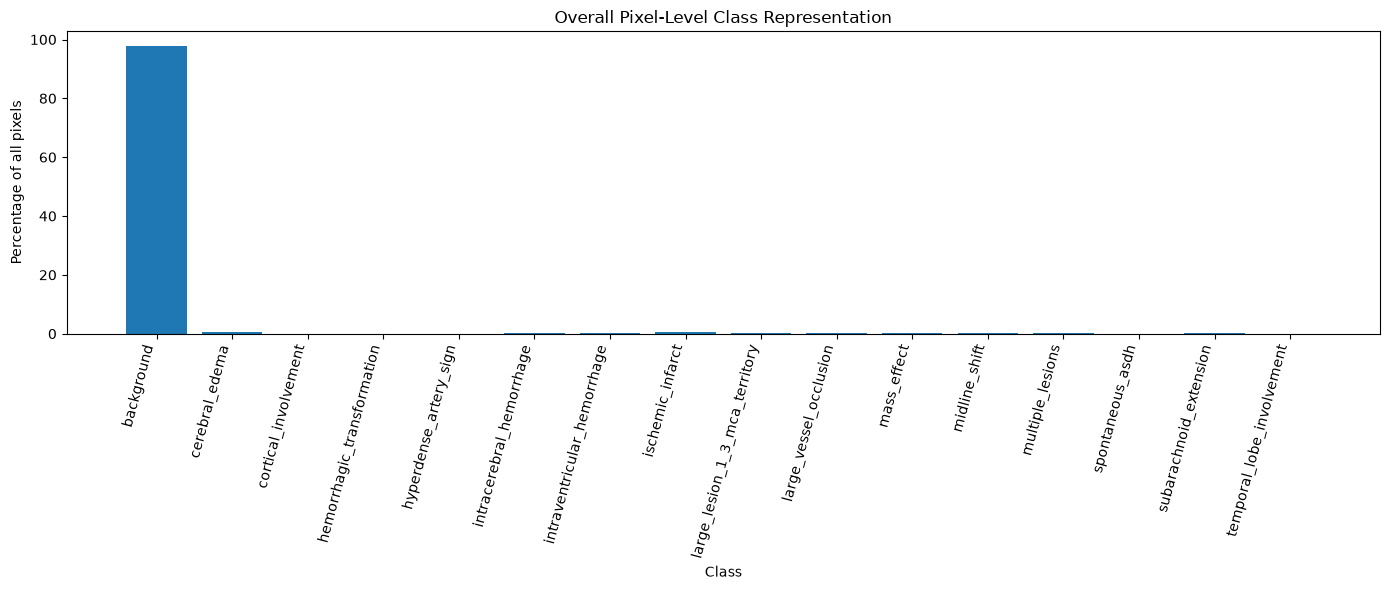

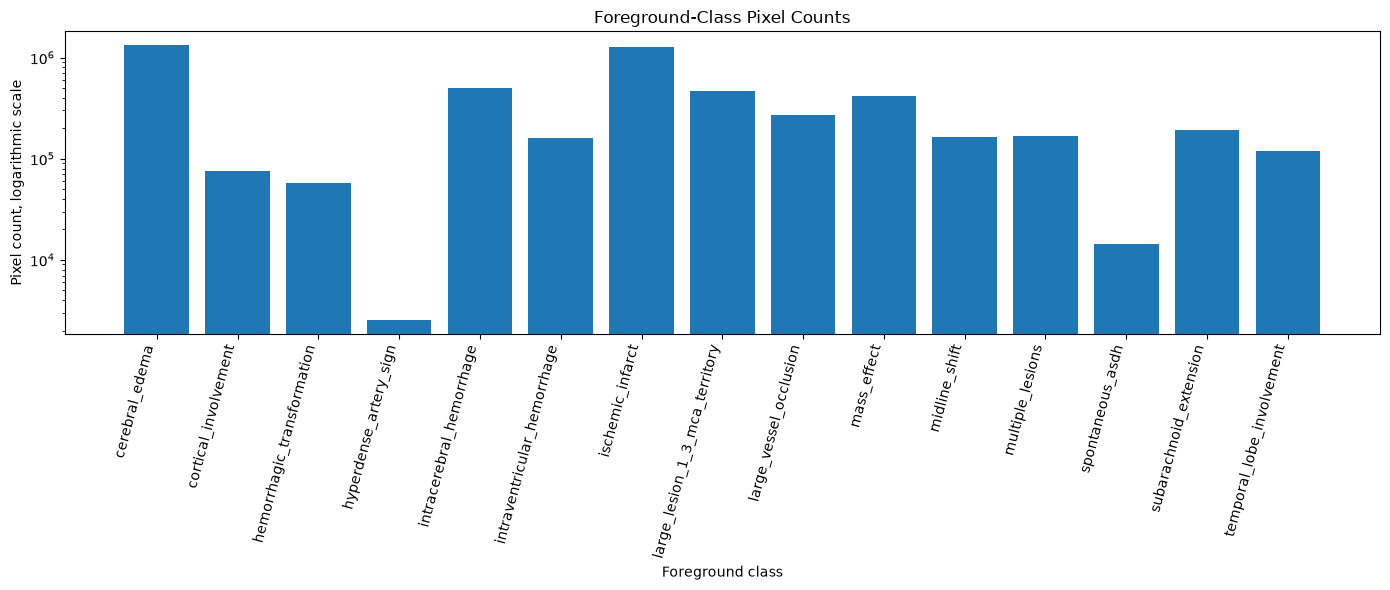

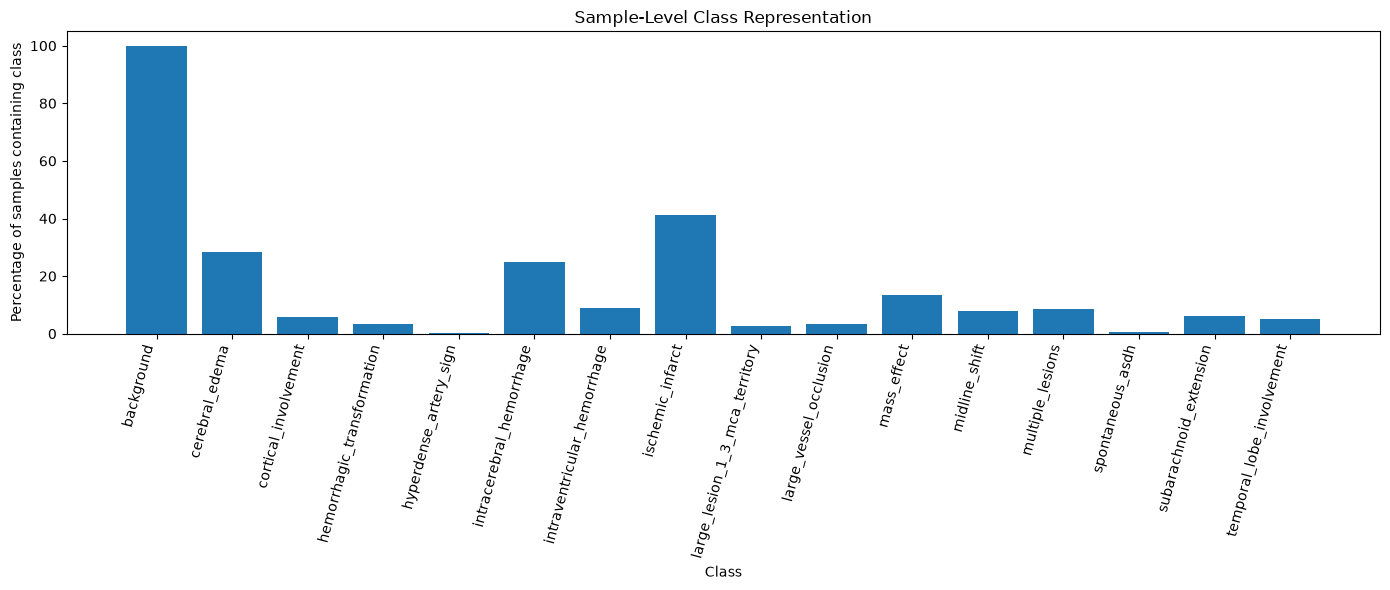

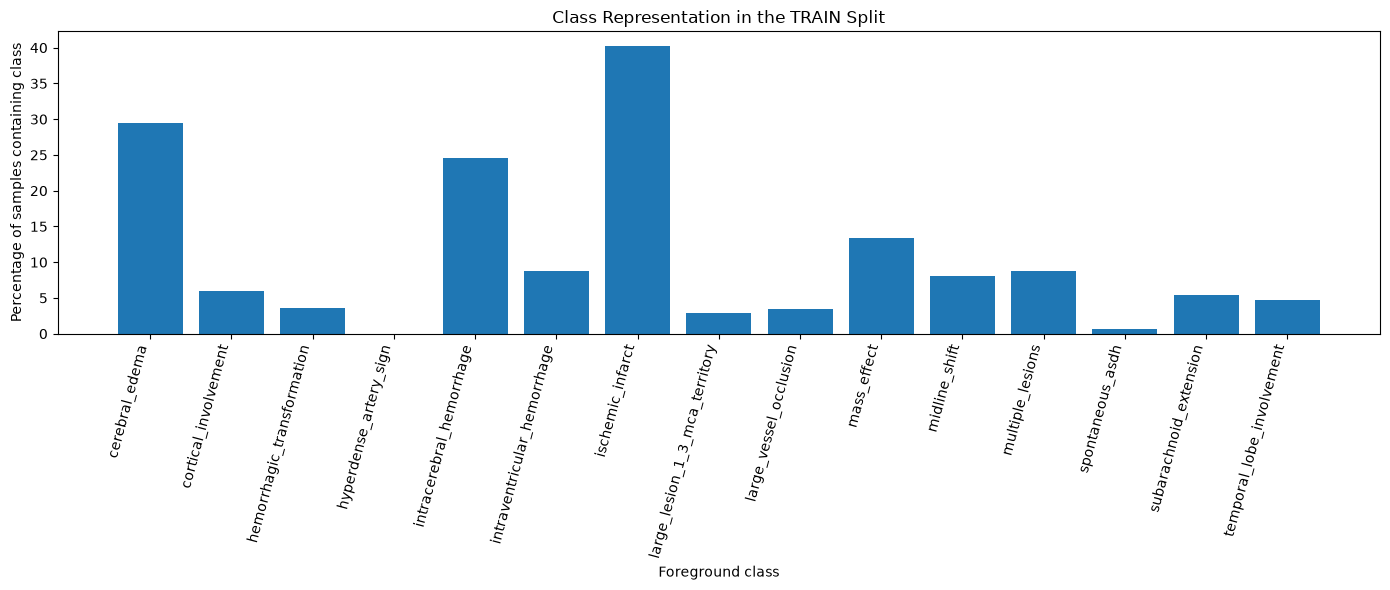

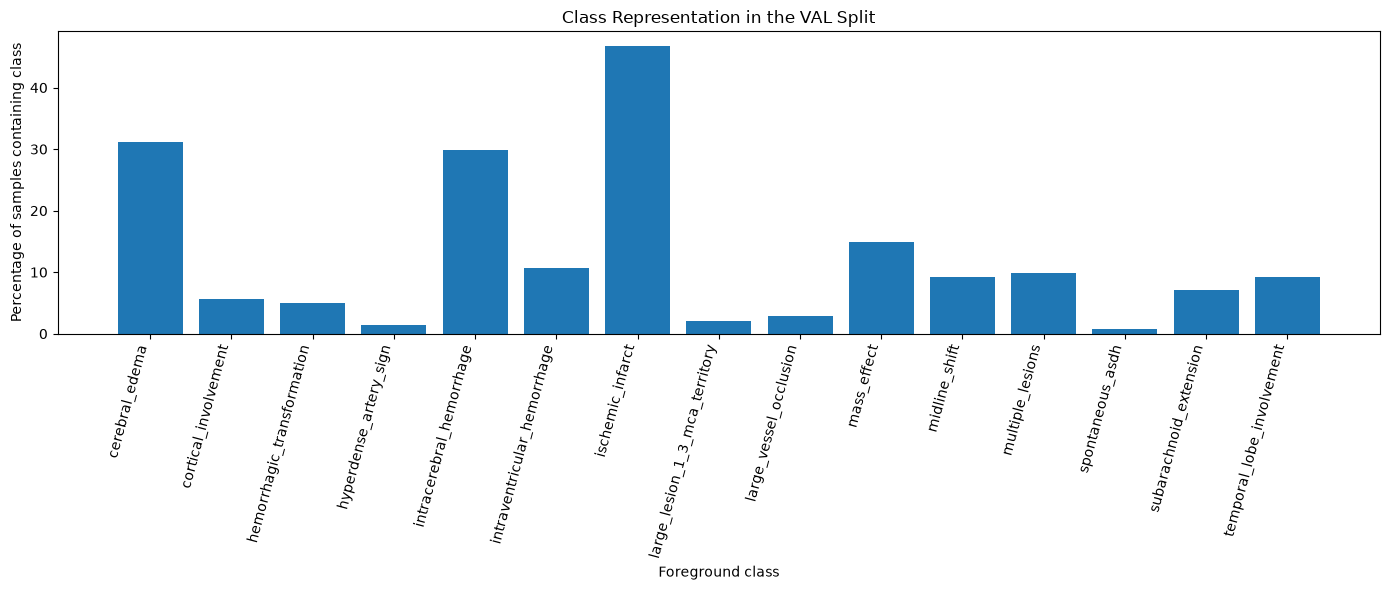

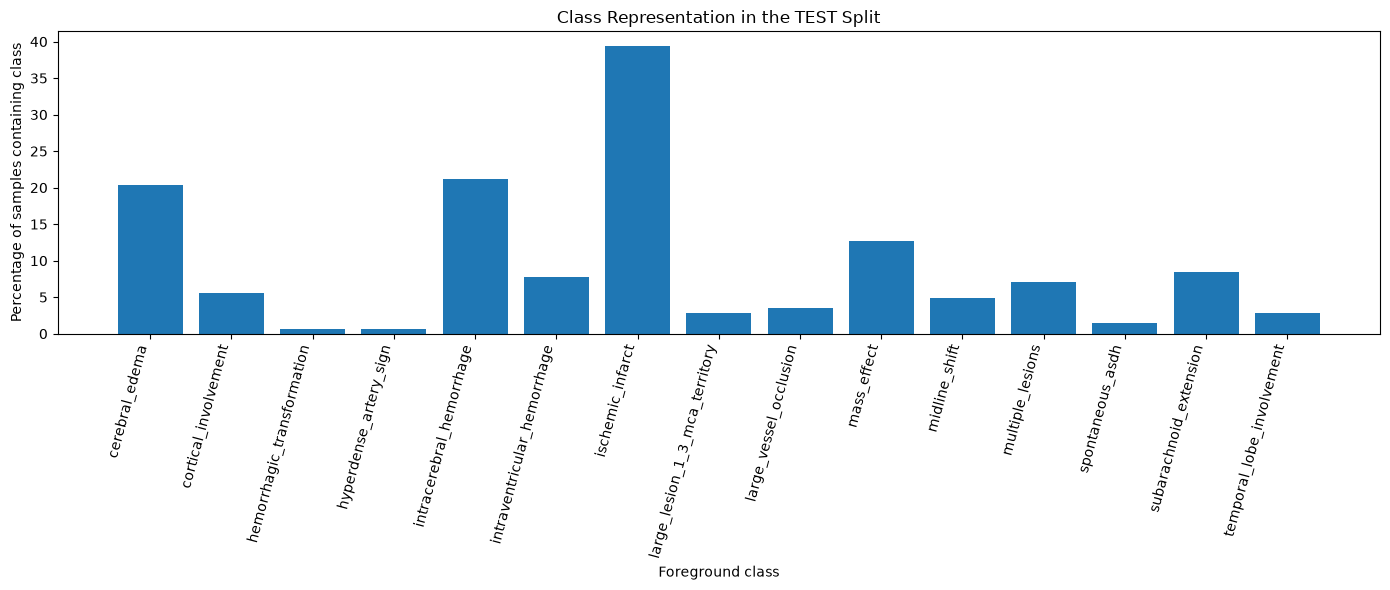

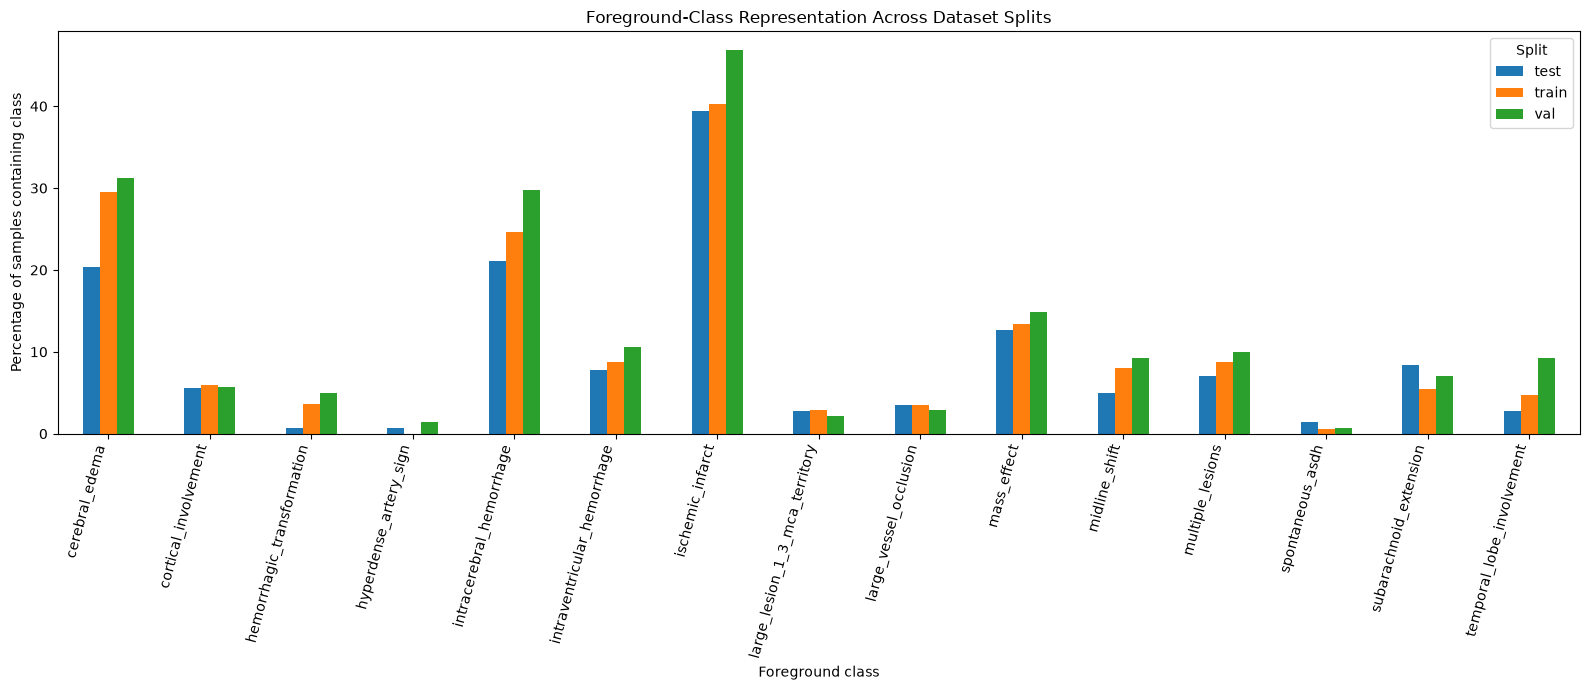

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, List, Optional, Set
from tqdm.auto import tqdm


# =========================================================
# CONFIGURATION
# =========================================================

# For masks containing:
#   0    = background
#   1-16 = biomarker classes
NUM_CLASSES = 16
BACKGROUND_CLASS_ID = 0

ALLOWED_CLASS_IDS = set(range(NUM_CLASSES))


# Replace these names with your actual biomarker names.
CLASS_NAMES = {
    0: "background",
    1: "cerebral_edema",
    2: "cortical_involvement",
    3: "hemorrhagic_transformation",
    4: "hyperdense_artery_sign",
    5: "intracerebral_hemorrhage",
    6: "intraventricular_hemorrhage",
    7: "ischemic_infarct",
    8: "large_lesion_1_3_mca_territory",
    9: "large_vessel_occlusion",
    10: "mass_effect",
    11: "midline_shift",
    12: "multiple_lesions",
    13: "spontaneous_asdh",
    14: "subarachnoid_extension",
    15: "temporal_lobe_involvement",
}


# =========================================================
# CLASS REPRESENTATION ANALYSIS
# =========================================================

def analyse_class_representation(
    splits: Dict[str, List["Sample"]],
    allowed_class_ids: Optional[Set[int]] = None,
    class_names: Optional[Dict[int, str]] = None,
):
    """
    Analyse multiclass segmentation-mask representation.

    Produces:
        1. Per-split class statistics
        2. Overall class statistics
        3. Suggested CrossEntropyLoss weights
        4. Dataset imbalance summary
    """

    if allowed_class_ids is None:
        allowed_class_ids = set(range(NUM_CLASSES))

    class_ids = sorted(allowed_class_ids)

    if class_names is None:
        class_names = {
            class_id: f"Class {class_id}"
            for class_id in class_ids
        }

    split_records = []

    overall_pixel_counts = defaultdict(int)
    overall_sample_counts = defaultdict(int)

    overall_total_pixels = 0
    overall_total_samples = 0

    # -----------------------------------------------------
    # Process each split
    # -----------------------------------------------------
    for split_name, samples in splits.items():

        split_pixel_counts = defaultdict(int)
        split_sample_counts = defaultdict(int)

        split_total_pixels = 0
        split_total_samples = len(samples)

        for sample in tqdm(
            samples,
            desc=f"Analysing {split_name}",
        ):
            mask = normalize_multiclass_mask(
                read_mask(sample.mask_path),
                allowed_class_ids=allowed_class_ids,
            )

            split_total_pixels += int(mask.size)
            overall_total_pixels += int(mask.size)

            class_values, pixel_counts = np.unique(
                mask,
                return_counts=True,
            )

            # Pixel-level class counts
            for class_id, pixel_count in zip(
                class_values,
                pixel_counts,
            ):
                class_id = int(class_id)
                pixel_count = int(pixel_count)

                split_pixel_counts[class_id] += pixel_count
                overall_pixel_counts[class_id] += pixel_count

            # Slice/sample-level occurrence counts
            classes_present = set(
                int(class_id)
                for class_id in class_values
            )

            for class_id in classes_present:
                split_sample_counts[class_id] += 1
                overall_sample_counts[class_id] += 1

        overall_total_samples += split_total_samples

        # -------------------------------------------------
        # Create per-split records
        # -------------------------------------------------
        for class_id in class_ids:

            pixel_count = split_pixel_counts.get(
                class_id,
                0,
            )

            samples_with_class = split_sample_counts.get(
                class_id,
                0,
            )

            pixel_percentage = (
                100 * pixel_count / split_total_pixels
                if split_total_pixels > 0
                else 0.0
            )

            sample_percentage = (
                100 * samples_with_class / split_total_samples
                if split_total_samples > 0
                else 0.0
            )

            average_pixels_when_present = (
                pixel_count / samples_with_class
                if samples_with_class > 0
                else 0.0
            )

            split_records.append(
                {
                    "split": split_name,
                    "class_id": class_id,
                    "class_name": class_names.get(
                        class_id,
                        f"Class {class_id}",
                    ),
                    "pixel_count": pixel_count,
                    "pixel_percentage": pixel_percentage,
                    "samples_with_class": samples_with_class,
                    "total_samples": split_total_samples,
                    "sample_presence_percentage": sample_percentage,
                    "average_pixels_when_present": (
                        average_pixels_when_present
                    ),
                    "missing_from_split": (
                        samples_with_class == 0
                    ),
                }
            )

    split_report = pd.DataFrame(split_records)

    # -----------------------------------------------------
    # Overall class representation
    # -----------------------------------------------------
    overall_records = []

    for class_id in class_ids:

        pixel_count = overall_pixel_counts.get(
            class_id,
            0,
        )

        samples_with_class = overall_sample_counts.get(
            class_id,
            0,
        )

        pixel_percentage = (
            100 * pixel_count / overall_total_pixels
            if overall_total_pixels > 0
            else 0.0
        )

        sample_presence_percentage = (
            100 * samples_with_class / overall_total_samples
            if overall_total_samples > 0
            else 0.0
        )

        average_pixels_when_present = (
            pixel_count / samples_with_class
            if samples_with_class > 0
            else 0.0
        )

        overall_records.append(
            {
                "class_id": class_id,
                "class_name": class_names.get(
                    class_id,
                    f"Class {class_id}",
                ),
                "pixel_count": pixel_count,
                "pixel_percentage": pixel_percentage,
                "samples_with_class": samples_with_class,
                "total_samples": overall_total_samples,
                "sample_presence_percentage": (
                    sample_presence_percentage
                ),
                "average_pixels_when_present": (
                    average_pixels_when_present
                ),
                "missing_from_dataset": pixel_count == 0,
            }
        )

    overall_report = pd.DataFrame(overall_records)

    # -----------------------------------------------------
    # Calculate imbalance statistics
    # -----------------------------------------------------
    foreground_report = overall_report[
        overall_report["class_id"] != BACKGROUND_CLASS_ID
    ].copy()

    represented_foreground = foreground_report[
        foreground_report["pixel_count"] > 0
    ].copy()

    if len(represented_foreground) > 0:

        most_common_row = represented_foreground.loc[
            represented_foreground["pixel_count"].idxmax()
        ]

        least_common_row = represented_foreground.loc[
            represented_foreground["pixel_count"].idxmin()
        ]

        foreground_imbalance_ratio = (
            most_common_row["pixel_count"]
            / least_common_row["pixel_count"]
        )

        imbalance_summary = {
            "most_common_foreground_class": (
                most_common_row["class_name"]
            ),
            "most_common_foreground_class_id": int(
                most_common_row["class_id"]
            ),
            "most_common_foreground_pixels": int(
                most_common_row["pixel_count"]
            ),
            "least_common_foreground_class": (
                least_common_row["class_name"]
            ),
            "least_common_foreground_class_id": int(
                least_common_row["class_id"]
            ),
            "least_common_foreground_pixels": int(
                least_common_row["pixel_count"]
            ),
            "foreground_imbalance_ratio": (
                foreground_imbalance_ratio
            ),
        }

    else:
        imbalance_summary = {
            "most_common_foreground_class": None,
            "most_common_foreground_class_id": None,
            "most_common_foreground_pixels": 0,
            "least_common_foreground_class": None,
            "least_common_foreground_class_id": None,
            "least_common_foreground_pixels": 0,
            "foreground_imbalance_ratio": np.nan,
        }

    # -----------------------------------------------------
    # Calculate suggested class weights
    # -----------------------------------------------------
    pixel_counts_array = np.array(
        [
            overall_pixel_counts.get(class_id, 0)
            for class_id in class_ids
        ],
        dtype=np.float64,
    )

    class_weights = calculate_class_weights(
        pixel_counts=pixel_counts_array,
    )

    weights_report = pd.DataFrame(
        {
            "class_id": class_ids,
            "class_name": [
                class_names.get(
                    class_id,
                    f"Class {class_id}",
                )
                for class_id in class_ids
            ],
            "pixel_count": pixel_counts_array.astype(
                np.int64
            ),
            "class_weight": class_weights,
        }
    )

    return {
        "split_report": split_report,
        "overall_report": overall_report,
        "weights_report": weights_report,
        "imbalance_summary": imbalance_summary,
    }


# =========================================================
# CALCULATE CLASS WEIGHTS
# =========================================================

def calculate_class_weights(
    pixel_counts: np.ndarray,
    maximum_weight: float = 20.0,
) -> np.ndarray:
    """
    Calculate square-root inverse-frequency class weights.

    Square-root inverse frequency is less extreme than using
    direct inverse frequency and is usually more stable for
    highly imbalanced segmentation datasets.

    Classes with zero pixels receive weight 0 because they
    cannot contribute to training.
    """

    pixel_counts = np.asarray(
        pixel_counts,
        dtype=np.float64,
    )

    weights = np.zeros_like(
        pixel_counts,
        dtype=np.float64,
    )

    represented_classes = pixel_counts > 0

    if not represented_classes.any():
        return weights.astype(np.float32)

    total_represented_pixels = pixel_counts[
        represented_classes
    ].sum()

    frequencies = (
        pixel_counts[represented_classes]
        / total_represented_pixels
    )

    inverse_frequency_weights = np.sqrt(
        1.0 / frequencies
    )

    # Normalize represented classes so their mean weight is 1.
    inverse_frequency_weights /= (
        inverse_frequency_weights.mean()
    )

    # Prevent extremely rare classes from receiving unstable weights.
    inverse_frequency_weights = np.clip(
        inverse_frequency_weights,
        a_min=0.0,
        a_max=maximum_weight,
    )

    weights[represented_classes] = (
        inverse_frequency_weights
    )

    return weights.astype(np.float32)


# =========================================================
# DISPLAY REPORTS
# =========================================================

analysis_results = analyse_class_representation(
    splits=splits,
    allowed_class_ids=ALLOWED_CLASS_IDS,
    class_names=CLASS_NAMES,
)

split_class_report = analysis_results["split_report"]
overall_class_report = analysis_results["overall_report"]
class_weights_report = analysis_results["weights_report"]
imbalance_summary = analysis_results["imbalance_summary"]


print("\nOVERALL CLASS REPRESENTATION")
display(
    overall_class_report[
        [
            "class_id",
            "class_name",
            "pixel_count",
            "pixel_percentage",
            "samples_with_class",
            "sample_presence_percentage",
            "missing_from_dataset",
        ]
    ].round(4)
)


print("\nCLASS REPRESENTATION BY SPLIT")
display(
    split_class_report[
        [
            "split",
            "class_id",
            "class_name",
            "pixel_count",
            "pixel_percentage",
            "samples_with_class",
            "sample_presence_percentage",
            "missing_from_split",
        ]
    ].round(4)
)


print("\nSUGGESTED CLASS WEIGHTS")
display(
    class_weights_report.round(4)
)


print("\nFOREGROUND IMBALANCE SUMMARY")

for key, value in imbalance_summary.items():
    print(f"{key}: {value}")


# =========================================================
# IDENTIFY MISSING AND RARE CLASSES
# =========================================================

missing_classes = overall_class_report[
    overall_class_report["missing_from_dataset"]
]

rare_classes = overall_class_report[
    (
        overall_class_report["class_id"]
        != BACKGROUND_CLASS_ID
    )
    & (
        overall_class_report[
            "sample_presence_percentage"
        ] < 1.0
    )
    & (
        ~overall_class_report[
            "missing_from_dataset"
        ]
    )
]


print("\nCLASSES MISSING FROM THE ENTIRE DATASET")
display(
    missing_classes[
        [
            "class_id",
            "class_name",
        ]
    ]
)


print("\nFOREGROUND CLASSES PRESENT IN LESS THAN 1% OF SAMPLES")
display(
    rare_classes[
        [
            "class_id",
            "class_name",
            "samples_with_class",
            "sample_presence_percentage",
            "pixel_percentage",
        ]
    ].round(6)
)


print("\nCLASSES MISSING FROM INDIVIDUAL SPLITS")
display(
    split_class_report[
        split_class_report["missing_from_split"]
    ][
        [
            "split",
            "class_id",
            "class_name",
        ]
    ]
)


# =========================================================
# PLOT 1: OVERALL PIXEL REPRESENTATION
# =========================================================

plot_data = overall_class_report.copy()

plt.figure(figsize=(14, 6))

plt.bar(
    plot_data["class_name"],
    plot_data["pixel_percentage"],
)

plt.xlabel("Class")
plt.ylabel("Percentage of all pixels")
plt.title("Overall Pixel-Level Class Representation")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


# =========================================================
# PLOT 2: FOREGROUND PIXEL REPRESENTATION ON LOG SCALE
# =========================================================

foreground_plot_data = overall_class_report[
    overall_class_report["class_id"]
    != BACKGROUND_CLASS_ID
].copy()

plt.figure(figsize=(14, 6))

plt.bar(
    foreground_plot_data["class_name"],
    foreground_plot_data["pixel_count"],
)

plt.yscale("log")
plt.xlabel("Foreground class")
plt.ylabel("Pixel count, logarithmic scale")
plt.title("Foreground-Class Pixel Counts")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


# =========================================================
# PLOT 3: SAMPLE-LEVEL CLASS OCCURRENCE
# =========================================================

plt.figure(figsize=(14, 6))

plt.bar(
    overall_class_report["class_name"],
    overall_class_report[
        "sample_presence_percentage"
    ],
)

plt.xlabel("Class")
plt.ylabel("Percentage of samples containing class")
plt.title("Sample-Level Class Representation")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


# =========================================================
# PLOT 4: REPRESENTATION BY DATASET SPLIT
# =========================================================

for split_name in split_class_report["split"].unique():

    current_split = split_class_report[
        split_class_report["split"] == split_name
    ].copy()

    current_split = current_split[
        current_split["class_id"]
        != BACKGROUND_CLASS_ID
    ]

    plt.figure(figsize=(14, 6))

    plt.bar(
        current_split["class_name"],
        current_split[
            "sample_presence_percentage"
        ],
    )

    plt.xlabel("Foreground class")
    plt.ylabel("Percentage of samples containing class")
    plt.title(
        f"Class Representation in the "
        f"{split_name.upper()} Split"
    )
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()


# =========================================================
# PLOT 5: TRAIN, VALIDATION AND TEST COMPARISON
# =========================================================

split_pivot = split_class_report.pivot(
    index="class_name",
    columns="split",
    values="sample_presence_percentage",
)

# Keep classes in class-ID order.
ordered_class_names = [
    CLASS_NAMES[class_id]
    for class_id in sorted(ALLOWED_CLASS_IDS)
    if class_id != BACKGROUND_CLASS_ID
]

available_names = [
    name
    for name in ordered_class_names
    if name in split_pivot.index
]

split_pivot = split_pivot.loc[available_names]

split_pivot.plot(
    kind="bar",
    figsize=(16, 7),
)

plt.xlabel("Foreground class")
plt.ylabel("Percentage of samples containing class")
plt.title(
    "Foreground-Class Representation Across Dataset Splits"
)
plt.xticks(rotation=75, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

## 9. Persist the exact split manifest

In [20]:
manifest_rows = []
for split_name, samples in splits.items():
    for sample in samples:
        manifest_rows.append(
            {
                "split": split_name,
                "sample_id": sample.sample_id,
                "patient_id": sample.patient_id,
                "image_path": sample.image_path,
                "mask_path": sample.mask_path,
            }
        )

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = OUTPUT_ROOT / "split_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)
print("Saved:", manifest_path)
manifest_df.head()

Saved: /workspace/bash_phd/ml_pipeline/outputs/transunet_stroke/split_manifest.csv


,split,sample_id,patient_id,image_path,mask_path
0,train,16239,16239,/workspace/bash_phd/ml_pipeline/stroke_dataset...,/workspace/bash_phd/ml_pipeline/stroke_dataset...
1,train,16243,16243,/workspace/bash_phd/ml_pipeline/stroke_dataset...,/workspace/bash_phd/ml_pipeline/stroke_dataset...
2,train,16272,16272,/workspace/bash_phd/ml_pipeline/stroke_dataset...,/workspace/bash_phd/ml_pipeline/stroke_dataset...
3,train,16279,16279,/workspace/bash_phd/ml_pipeline/stroke_dataset...,/workspace/bash_phd/ml_pipeline/stroke_dataset...
4,train,16323,16323,/workspace/bash_phd/ml_pipeline/stroke_dataset...,/workspace/bash_phd/ml_pipeline/stroke_dataset...


## 10. Visual dataset sanity check

/tmp/ipykernel_3063/3249796345.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


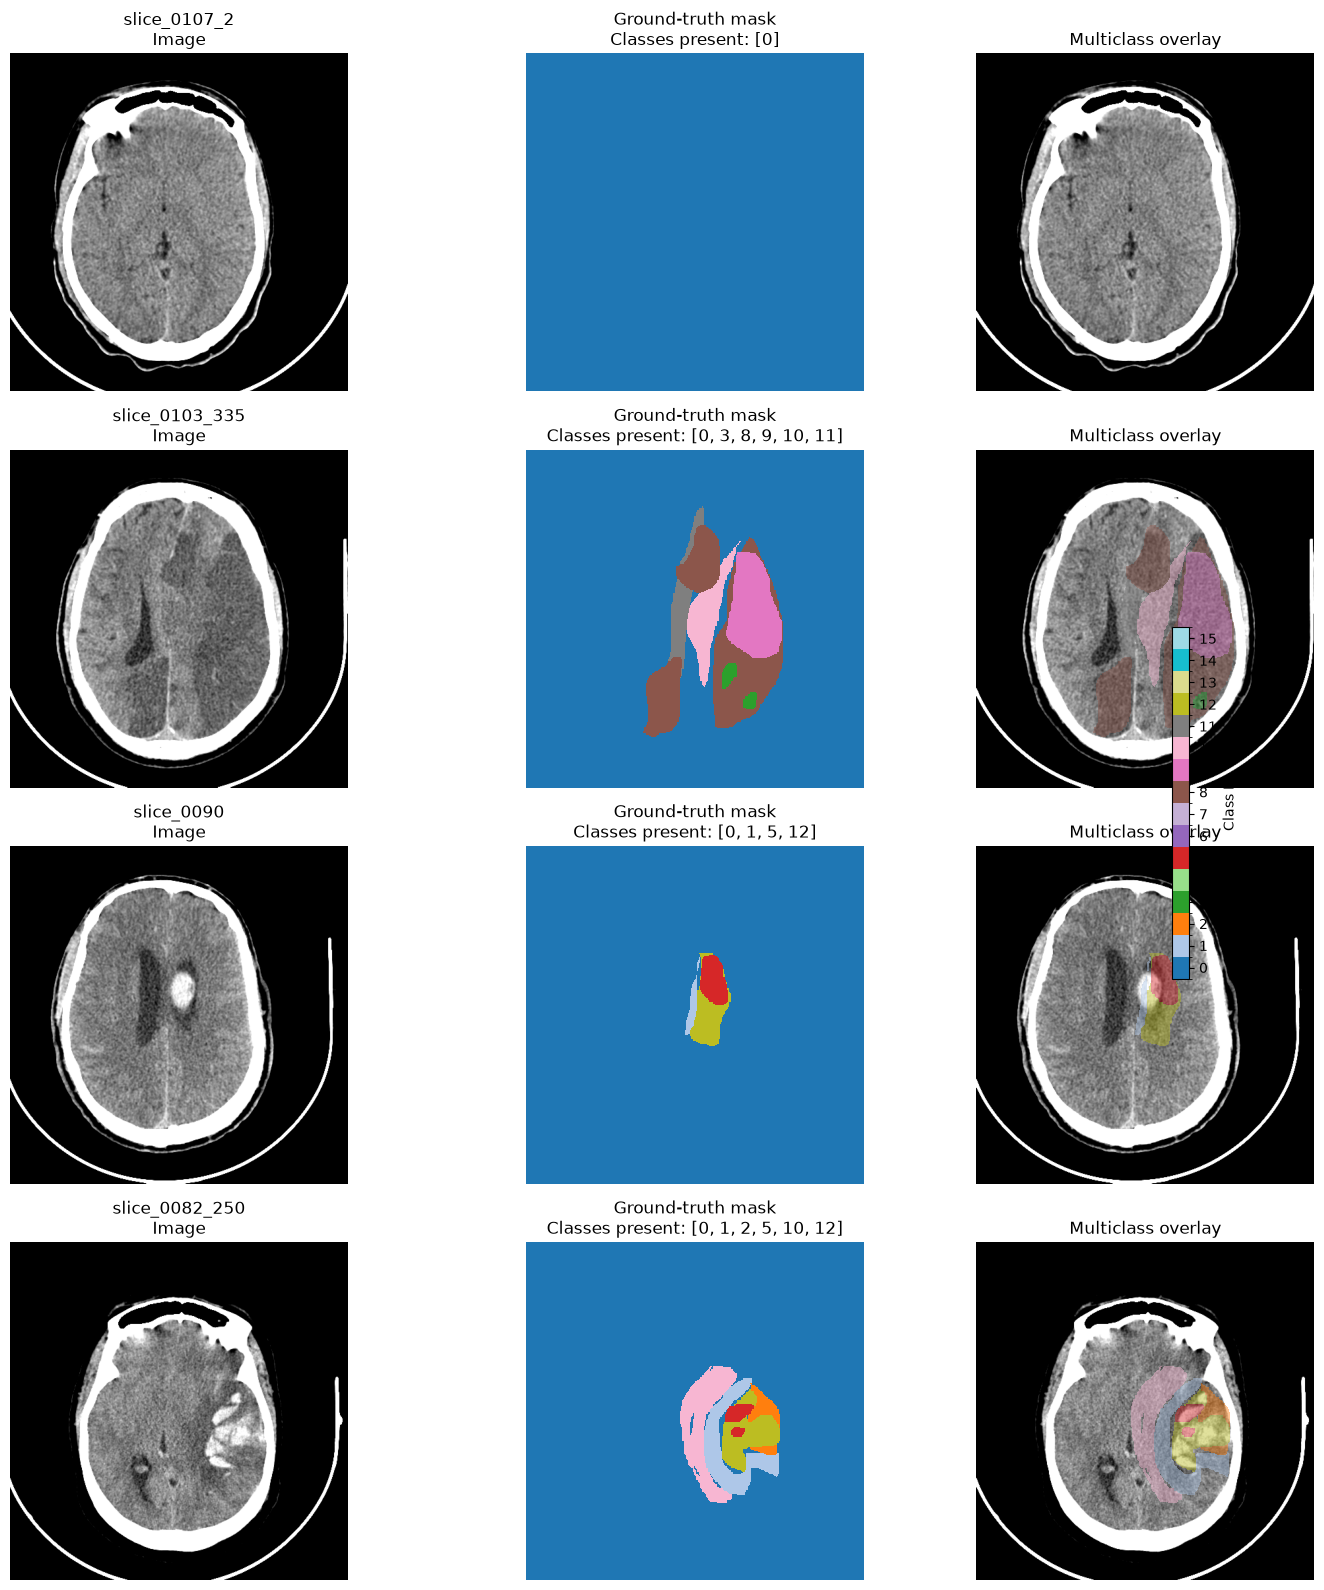

In [21]:
# def show_samples(samples: Sequence[Sample], n: int = 4) -> None:
#     chosen = random.sample(list(samples), k=min(n, len(samples)))
#     fig, axes = plt.subplots(len(chosen), 3, figsize=(12, 4 * len(chosen)))
#     axes = np.atleast_2d(axes)

#     for row, sample in enumerate(chosen):
#         image = read_image(sample.image_path)
#         mask = normalize_binary_mask(read_mask(sample.mask_path))

#         if image.ndim == 2:
#             display_image = image
#             cmap = "gray"
#         else:
#             display_image = image
#             cmap = None

#         axes[row, 0].imshow(display_image, cmap=cmap)
#         axes[row, 0].set_title(f"{sample.sample_id}: image")
#         axes[row, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
#         axes[row, 1].set_title("Ground-truth mask")
#         axes[row, 2].imshow(display_image, cmap=cmap)
#         axes[row, 2].imshow(mask, alpha=0.35, cmap="Reds", vmin=0, vmax=1)
#         axes[row, 2].set_title("Overlay")

#         for ax in axes[row]:
#             ax.axis("off")

#     plt.tight_layout()
#     plt.show()


# show_samples(splits["train"])
####################################################################
# UPDATED
####################################################################
import random
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm


def show_samples(
    samples: Sequence["Sample"],
    n: int = 4,
    allowed_class_ids=None,
) -> None:
    """
    Display random images, multiclass masks, and overlays.

    Assumes:
        0 = background
        1...N = segmentation classes
    """

    samples = list(samples)

    if len(samples) == 0:
        print("No samples are available to display.")
        return

    number_to_show = min(n, len(samples))
    chosen = random.sample(samples, k=number_to_show)

    # Determine class IDs used for visualization.
    if allowed_class_ids is None:
        allowed_class_ids = ALLOWED_CLASS_IDS

    class_ids = sorted(allowed_class_ids)
    maximum_class_id = max(class_ids)

    # Discrete multiclass colour map.
    cmap = plt.get_cmap(
        "tab20",
        maximum_class_id + 1,
    )

    boundaries = np.arange(
        -0.5,
        maximum_class_id + 1.5,
        1,
    )

    norm = BoundaryNorm(
        boundaries,
        cmap.N,
    )

    fig, axes = plt.subplots(
        number_to_show,
        3,
        figsize=(14, 4 * number_to_show),
        squeeze=False,
    )

    for row, sample in enumerate(chosen):
        image = read_image(sample.image_path)

        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            allowed_class_ids=allowed_class_ids,
        )

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                f"Image-mask shape mismatch for {sample.sample_id}: "
                f"image={image.shape}, mask={mask.shape}"
            )

        if image.ndim == 2:
            display_image = image
            image_cmap = "gray"
        else:
            display_image = image
            image_cmap = None

        classes_present = np.unique(mask).tolist()

        # -------------------------------------------------
        # Original image
        # -------------------------------------------------
        axes[row, 0].imshow(
            display_image,
            cmap=image_cmap,
        )

        axes[row, 0].set_title(
            f"{sample.sample_id}\nImage"
        )

        # -------------------------------------------------
        # Multiclass ground-truth mask
        # -------------------------------------------------
        mask_plot = axes[row, 1].imshow(
            mask,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
        )

        axes[row, 1].set_title(
            f"Ground-truth mask\n"
            f"Classes present: {classes_present}"
        )

        # -------------------------------------------------
        # Image-mask overlay
        # -------------------------------------------------
        axes[row, 2].imshow(
            display_image,
            cmap=image_cmap,
        )

        # Hide background class 0 from the overlay.
        foreground_mask = np.ma.masked_where(
            mask == 0,
            mask,
        )

        axes[row, 2].imshow(
            foreground_mask,
            cmap=cmap,
            norm=norm,
            alpha=0.45,
            interpolation="nearest",
        )

        axes[row, 2].set_title(
            "Multiclass overlay"
        )

        for axis in axes[row]:
            axis.axis("off")

    # Shared colour bar.
    colour_bar = fig.colorbar(
        mask_plot,
        ax=axes[:, 1:].ravel().tolist(),
        ticks=class_ids,
        fraction=0.025,
        pad=0.02,
    )

    colour_bar.set_label("Class ID")

    plt.tight_layout()
    plt.show()


show_samples(
    splits["train"],
    n=4,
    allowed_class_ids=ALLOWED_CLASS_IDS,
)

## 11. Augmentation pipelines
For your multiclass CT segmentation, class imbalance can occur in two ways:

###### *Sample imbalance:* a rare biomarker appears in very few CT slices.

###### *Pixel imbalance:* the biomarker appears in a slice but occupies only a small region.

Random augmentation alone does not fully solve either problem. The most effective combination is:

1. Oversample slices containing rare classes.
2. Crop around rare-class pixels.
3. Apply moderate geometric and CT intensity augmentations.
4. Use class-aware loss alongside augmentation.
5. Keep validation and test data unchanged.

#### Oversample slices containing rare classes.

In [25]:
import random
from collections import Counter
from typing import Dict, List, Optional, Sequence, Set, Tuple

import albumentations as A
import cv2
import numpy as np
import pandas as pd
import torch

from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm


# =========================================================
# CONFIGURATION
# =========================================================

BACKGROUND_CLASS_ID = 0

# Your report contains class IDs 0–15:
# 0 = background
# 1–15 = foreground biomarkers
NUM_CLASSES = 16
ALLOWED_CLASS_IDS = set(range(NUM_CLASSES))

IMAGE_SIZE = 256
RANDOM_SEED = 42


CLASS_NAMES = {
    0: "background",
    1: "cerebral_edema",
    2: "cortical_involvement",
    3: "hemorrhagic_transformation",
    4: "hyperdense_artery_sign",
    5: "intracerebral_hemorrhage",
    6: "intraventricular_hemorrhage",
    7: "ischemic_infarct",
    8: "large_lesion_1_3_mca_territory",
    9: "large_vessel_occlusion",
    10: "mass_effect",
    11: "midline_shift",
    12: "multiple_lesions",
    13: "spontaneous_asdh",
    14: "subarachnoid_extension",
    15: "temporal_lobe_involvement",
}


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# =========================================================
# DERIVE TRAINING STATISTICS
# =========================================================

train_class_statistics = (
    split_class_report[
        split_class_report["split"] == "train"
    ]
    .copy()
    .sort_values("class_id")
)

train_class_statistics["average_pixels_when_present"] = np.where(
    train_class_statistics["samples_with_class"] > 0,
    (
        train_class_statistics["pixel_count"]
        / train_class_statistics["samples_with_class"]
    ),
    0.0,
)


TRAIN_SAMPLE_COUNTS = {
    int(row.class_id): int(row.samples_with_class)
    for row in train_class_statistics.itertuples()
}

TRAIN_AVERAGE_PIXELS = {
    int(row.class_id): float(row.average_pixels_when_present)
    for row in train_class_statistics.itertuples()
}


def assign_class_tier(number_of_samples: int) -> str:
    """Assign an imbalance tier using training-split occurrence."""

    if number_of_samples == 0:
        return "missing"

    if number_of_samples <= 5:
        return "ultra_rare"

    if number_of_samples <= 25:
        return "very_rare"

    if number_of_samples <= 50:
        return "rare"

    if number_of_samples <= 100:
        return "moderate"

    return "common"


CLASS_TIERS = {
    class_id: assign_class_tier(
        TRAIN_SAMPLE_COUNTS.get(class_id, 0)
    )
    for class_id in sorted(ALLOWED_CLASS_IDS)
    if class_id != BACKGROUND_CLASS_ID
}


# Oversampling multiplier for a slice containing a class.
TIER_SAMPLING_MULTIPLIER = {
    "missing": 0.0,
    "ultra_rare": 7.0,
    "very_rare": 4.5,
    "rare": 2.8,
    "moderate": 1.6,
    "common": 1.0,
}


# Probability that a class-centred crop is applied.
TIER_CROP_PROBABILITY = {
    "missing": 0.0,
    "ultra_rare": 0.90,
    "very_rare": 0.85,
    "rare": 0.75,
    "moderate": 0.55,
    "common": 0.30,
}


# Base crop size before resizing to IMAGE_SIZE.
# Smaller crops magnify small biomarkers.
TIER_CROP_SIZE = {
    "ultra_rare": 192,
    "very_rare": 224,
    "rare": 256,
    "moderate": 288,
    "common": 320,
}


policy_records = []

for class_id, tier in CLASS_TIERS.items():
    policy_records.append(
        {
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "training_samples": TRAIN_SAMPLE_COUNTS[class_id],
            "average_pixels_when_present": (
                TRAIN_AVERAGE_PIXELS[class_id]
            ),
            "tier": tier,
            "sampling_multiplier": (
                TIER_SAMPLING_MULTIPLIER[tier]
            ),
            "crop_probability": (
                TIER_CROP_PROBABILITY[tier]
            ),
        }
    )

augmentation_policy_report = pd.DataFrame(policy_records)

display(augmentation_policy_report)

,class_id,class_name,training_samples,average_pixels_when_present,tier,sampling_multiplier,crop_probability
0,1,cerebral_edema,194,5078.525773,common,1.0,0.30
1,2,cortical_involvement,39,1431.974359,rare,2.8,0.75
2,3,hemorrhagic_transformation,24,1911.708333,very_rare,4.5,0.85
3,4,hyperdense_artery_sign,0,0.000000,missing,0.0,0.00
4,5,intracerebral_hemorrhage,162,2080.444444,common,1.0,0.30
5,6,intraventricular_hemorrhage,58,1780.551724,moderate,1.6,0.55
6,7,ischemic_infarct,265,3300.392453,common,1.0,0.30
7,8,large_lesion_1_3_mca_territory,19,19088.473684,very_rare,4.5,0.85
8,9,large_vessel_occlusion,23,9103.130435,very_rare,4.5,0.85
9,10,mass_effect,88,3351.534091,moderate,1.6,0.55


In [26]:
# Check where class 4 occurs

# Run this before constructing the final training dataset:
def locate_class_samples(
    splits: Dict[str, Sequence["Sample"]],
    target_class_id: int,
) -> pd.DataFrame:
    records = []

    for split_name, samples in splits.items():
        for sample in tqdm(
            samples,
            desc=f"Finding class {target_class_id} in {split_name}",
        ):
            mask = normalize_multiclass_mask(
                read_mask(sample.mask_path),
                allowed_class_ids=ALLOWED_CLASS_IDS,
            )

            target_pixels = int(
                np.count_nonzero(mask == target_class_id)
            )

            if target_pixels > 0:
                records.append(
                    {
                        "split": split_name,
                        "patient_id": sample.patient_id,
                        "sample_id": sample.sample_id,
                        "mask_path": sample.mask_path,
                        "target_pixels": target_pixels,
                    }
                )

    return pd.DataFrame(records)


class_4_locations = locate_class_samples(
    splits=splits,
    target_class_id=4,
)

display(class_4_locations)


Finding class 4 in train:   0%|          | 0/658 [00:00<?, ?it/s]

Finding class 4 in val:   0%|          | 0/141 [00:00<?, ?it/s]

Finding class 4 in test:   0%|          | 0/142 [00:00<?, ?it/s]

,split,patient_id,sample_id,mask_path,target_pixels
0,val,slice_0062_85,slice_0062_85,/workspace/bash_phd/ml_pipeline/stroke_dataset...,730
1,val,slice_0067_86,slice_0067_86,/workspace/bash_phd/ml_pipeline/stroke_dataset...,1120
2,test,slice_0079_327,slice_0079_327,/workspace/bash_phd/ml_pipeline/stroke_dataset...,695


In [27]:
# Build sample metadata once

# This avoids recalculating class occurrence every time the sampler is created
def build_sample_metadata(
    samples: Sequence["Sample"],
) -> List[Dict]:
    metadata = []

    for index, sample in enumerate(
        tqdm(samples, desc="Building training metadata")
    ):
        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            allowed_class_ids=ALLOWED_CLASS_IDS,
        )

        present_classes = tuple(
            int(class_id)
            for class_id in np.unique(mask)
            if int(class_id) != BACKGROUND_CLASS_ID
        )

        patient_id = getattr(
            sample,
            "patient_id",
            sample.sample_id,
        )

        metadata.append(
            {
                "index": index,
                "sample_id": sample.sample_id,
                "patient_id": patient_id,
                "classes_present": present_classes,
            }
        )

    return metadata


train_metadata = build_sample_metadata(
    splits["train"]
)

Building training metadata:   0%|          | 0/658 [00:00<?, ?it/s]

In [28]:
# Patient-adjusted weighted sampler

# A simple rare-slice sampler can repeatedly select many neighbouring slices from one patient and create the appearance of diversity. The following sampler reduces that problem by accounting for how many slices each patient contributes.
def build_class_aware_sampler(
    metadata: List[Dict],
    class_tiers: Dict[int, str],
    number_of_samples: Optional[int] = None,
    maximum_sample_weight: float = 8.0,
) -> Tuple[WeightedRandomSampler, np.ndarray]:

    patient_slice_counts = Counter(
        record["patient_id"]
        for record in metadata
    )

    patient_counts_array = np.asarray(
        list(patient_slice_counts.values()),
        dtype=np.float64,
    )

    median_patient_slices = float(
        np.median(patient_counts_array)
    )

    sample_weights = []

    for record in metadata:
        classes_present = record["classes_present"]

        if not classes_present:
            # Retain some negative/background-only slices.
            class_multiplier = 0.60

        else:
            class_multiplier = max(
                TIER_SAMPLING_MULTIPLIER[
                    class_tiers.get(class_id, "common")
                ]
                for class_id in classes_present
            )

        patient_slice_count = patient_slice_counts[
            record["patient_id"]
        ]

        # Patients with many slices should not dominate.
        patient_adjustment = (
            median_patient_slices
            / max(patient_slice_count, 1)
        )

        patient_adjustment = np.clip(
            patient_adjustment,
            a_min=0.25,
            a_max=4.0,
        )

        final_weight = (
            class_multiplier
            * patient_adjustment
        )

        sample_weights.append(final_weight)

    sample_weights = np.asarray(
        sample_weights,
        dtype=np.float64,
    )

    # Normalize around a mean of 1.
    sample_weights /= max(
        sample_weights.mean(),
        1e-8,
    )

    sample_weights = np.clip(
        sample_weights,
        a_min=0.15,
        a_max=maximum_sample_weight,
    )

    if number_of_samples is None:
        number_of_samples = len(metadata)

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(
            sample_weights,
            dtype=torch.double,
        ),
        num_samples=number_of_samples,
        replacement=True,
    )

    return sampler, sample_weights


train_sampler, train_sample_weights = (
    build_class_aware_sampler(
        metadata=train_metadata,
        class_tiers=CLASS_TIERS,
        number_of_samples=len(train_metadata),
    )
)


print(
    "Sampler weight range:",
    train_sample_weights.min(),
    "to",
    train_sample_weights.max(),
)

Sampler weight range: 0.4170275694517799 to 4.865321643604099


In [31]:
# Target-class selection and class-centred cropping
def select_target_class(
    mask: np.ndarray,
    class_tiers: Dict[int, str],
) -> Optional[int]:
    """
    Select one foreground class from a mask.

    Rare classes have a higher probability of becoming
    the crop target when multiple classes are present.
    """

    classes_present = [
        int(class_id)
        for class_id in np.unique(mask)
        if int(class_id) != BACKGROUND_CLASS_ID
    ]

    if not classes_present:
        return None

    target_weights = [
        TIER_SAMPLING_MULTIPLIER[
            class_tiers.get(class_id, "common")
        ]
        for class_id in classes_present
    ]

    return random.choices(
        classes_present,
        weights=target_weights,
        k=1,
    )[0]


def select_crop_size(
    target_class_id: int,
) -> int:
    """
    Select crop size using both class rarity and lesion size.

    Large lesions receive larger crops to preserve anatomical
    context even when they occur in few slices.
    """

    tier = CLASS_TIERS.get(
        target_class_id,
        "common",
    )

    base_crop_size = TIER_CROP_SIZE[tier]

    average_pixels = TRAIN_AVERAGE_PIXELS.get(
        target_class_id,
        0.0,
    )

    # Class 8 and other large lesions need more context.
    if average_pixels >= 8_000:
        return 320

    if average_pixels >= 4_000:
        return max(base_crop_size, 288)

    return base_crop_size


def pad_for_crop(
    image: np.ndarray,
    mask: np.ndarray,
    crop_size: int,
) -> Tuple[np.ndarray, np.ndarray]:

    height, width = mask.shape[:2]

    required_height = max(
        0,
        crop_size - height,
    )

    required_width = max(
        0,
        crop_size - width,
    )

    pad_top = required_height // 2
    pad_bottom = required_height - pad_top

    pad_left = required_width // 2
    pad_right = required_width - pad_left

    if required_height > 0 or required_width > 0:
        image = cv2.copyMakeBorder(
            image,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            borderType=cv2.BORDER_REFLECT_101,
        )

        mask = cv2.copyMakeBorder(
            mask,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            borderType=cv2.BORDER_CONSTANT,
            value=BACKGROUND_CLASS_ID,
        )

    return image, mask


def crop_around_target_class(
    image: np.ndarray,
    mask: np.ndarray,
    target_class_id: int,
    crop_size: int,
    jitter_fraction: float = 0.15,
) -> Tuple[np.ndarray, np.ndarray]:

    image, mask = pad_for_crop(
        image=image,
        mask=mask,
        crop_size=crop_size,
    )

    target_coordinates = np.argwhere(
        mask == target_class_id
    )

    if len(target_coordinates) == 0:
        return image, mask

    centre_y, centre_x = target_coordinates[
        random.randrange(len(target_coordinates))
    ]

    maximum_jitter = int(
        crop_size * jitter_fraction
    )

    centre_y += random.randint(
        -maximum_jitter,
        maximum_jitter,
    )

    centre_x += random.randint(
        -maximum_jitter,
        maximum_jitter,
    )

    height, width = mask.shape[:2]

    top = int(
        centre_y - crop_size // 2
    )

    left = int(
        centre_x - crop_size // 2
    )

    top = max(
        0,
        min(top, height - crop_size),
    )

    left = max(
        0,
        min(left, width - crop_size),
    )

    bottom = top + crop_size
    right = left + crop_size

    cropped_image = image[
        top:bottom,
        left:right,
    ]

    cropped_mask = mask[
        top:bottom,
        left:right,
    ]

    return cropped_image, cropped_mask

In [34]:
# train_transform = A.Compose(
#     [
#         A.Resize(CFG.image_size, CFG.image_size, interpolation=cv2.INTER_LINEAR),
#         A.HorizontalFlip(p=0.5),
#         A.ShiftScaleRotate(
#             shift_limit=0.05,
#             scale_limit=0.10,
#             rotate_limit=15,
#             border_mode=cv2.BORDER_CONSTANT,
#             value=0,
#             mask_value=0,
#             p=0.6,
#         ),
#         A.RandomBrightnessContrast(
#             brightness_limit=0.15,
#             contrast_limit=0.15,
#             p=0.35,
#         ),
#         A.GaussNoise(p=0.15),
#         A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
#         ToTensorV2(),
#     ]
# )

# eval_transform = A.Compose(
#     [
#         A.Resize(CFG.image_size, CFG.image_size, interpolation=cv2.INTER_LINEAR),
#         A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
#         ToTensorV2(),
#     ]
# )

train_transform = A.Compose(
    [
        A.Resize(
            height=IMAGE_SIZE,
            width=IMAGE_SIZE,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),

        # Safe because your labels do not encode left versus right.
        # Remove this if laterality is introduced.
        A.HorizontalFlip(
            p=0.50,
        ),

        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(-0.03, 0.03),
            rotate=(-7, 7),
            shear=(-2, 2),
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            fill_mask=BACKGROUND_CLASS_ID,
            p=0.65,
        ),

        # Mild intensity augmentation for scanner and
        # reconstruction variability.
        A.OneOf(
            [
                A.RandomBrightnessContrast(
                    brightness_limit=0.08,
                    contrast_limit=0.12,
                    p=1.0,
                ),
                A.RandomGamma(
                    gamma_limit=(92, 108),
                    p=1.0,
                ),
                A.CLAHE(
                    clip_limit=(1.0, 2.0),
                    tile_grid_size=(8, 8),
                    p=1.0,
                ),
            ],
            p=0.45,
        ),

        A.OneOf(
            [
                A.GaussNoise(
                    p=1.0,
                ),
                A.GaussianBlur(
                    blur_limit=(3, 3),
                    p=1.0,
                ),
            ],
            p=0.12,
        ),

        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
            max_pixel_value=255.0,
        ),

        ToTensorV2(),
    ],

    # Enforce nearest-neighbour interpolation for masks.
    mask_interpolation=cv2.INTER_NEAREST,
    seed=RANDOM_SEED,
)


validation_transform = A.Compose(
    [
        A.Resize(
            height=IMAGE_SIZE,
            width=IMAGE_SIZE,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),

        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
            max_pixel_value=255.0,
        ),

        ToTensorV2(),
    ],
    mask_interpolation=cv2.INTER_NEAREST,
)

In [35]:
# Dataset class
class ClassAwareStrokeDataset(Dataset):
    def __init__(
        self,
        samples: Sequence["Sample"],
        transform=None,
        training: bool = False,
        class_tiers: Optional[Dict[int, str]] = None,
    ):
        self.samples = list(samples)
        self.transform = transform
        self.training = training
        self.class_tiers = (
            class_tiers
            if class_tiers is not None
            else CLASS_TIERS
        )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        sample = self.samples[index]

        image = read_image(
            sample.image_path
        )

        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            allowed_class_ids=ALLOWED_CLASS_IDS,
        )

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                f"Shape mismatch for {sample.sample_id}: "
                f"image={image.shape}, mask={mask.shape}"
            )

        target_class_id = None

        if self.training:
            target_class_id = select_target_class(
                mask=mask,
                class_tiers=self.class_tiers,
            )

            if target_class_id is not None:
                target_tier = self.class_tiers[
                    target_class_id
                ]

                crop_probability = (
                    TIER_CROP_PROBABILITY[
                        target_tier
                    ]
                )

                if random.random() < crop_probability:
                    crop_size = select_crop_size(
                        target_class_id
                    )

                    image, mask = (
                        crop_around_target_class(
                            image=image,
                            mask=mask,
                            target_class_id=target_class_id,
                            crop_size=crop_size,
                        )
                    )

        # Convert grayscale CT to three channels for
        # TransUNet or similar pretrained models.
        if image.ndim == 2:
            image = np.repeat(
                image[..., None],
                repeats=3,
                axis=2,
            )

        elif image.ndim == 3 and image.shape[2] == 1:
            image = np.repeat(
                image,
                repeats=3,
                axis=2,
            )

        if self.transform is not None:
            transformed = self.transform(
                image=image,
                mask=mask,
            )

            image = transformed["image"].float()
            mask = transformed["mask"].long()

        else:
            image = torch.from_numpy(
                image.transpose(2, 0, 1)
            ).float()

            mask = torch.from_numpy(
                mask.astype(np.int64)
            )

        return {
            "image": image,
            "mask": mask,
            "sample_id": sample.sample_id,
            "patient_id": sample.patient_id,
            "target_class_id": (
                -1
                if target_class_id is None
                else target_class_id
            ),
        }

## 12. PyTorch dataset

#### Using class aware augmented sampling

In [36]:
#Construct Datasets and Loaders
train_dataset = ClassAwareStrokeDataset(
    samples=splits["train"],
    transform=train_transform,
    training=True,
    class_tiers=CLASS_TIERS,
)

val_dataset = ClassAwareStrokeDataset(
    samples=splits["val"],
    transform=validation_transform,
    training=False,
)

test_dataset = ClassAwareStrokeDataset(
    samples=splits["test"],
    transform=validation_transform,
    training=False,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    sampler=train_sampler,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

In [37]:
# Verify the augmented sampling distribution
from collections import Counter


def inspect_augmented_loader(
    data_loader,
    number_of_batches: int = 50,
) -> pd.DataFrame:

    class_slice_counts = Counter()
    class_pixel_counts = Counter()

    processed_samples = 0

    for batch_index, batch in enumerate(data_loader):
        if batch_index >= number_of_batches:
            break

        masks = batch["mask"].cpu().numpy()

        for mask in masks:
            processed_samples += 1

            class_ids, pixel_counts = np.unique(
                mask,
                return_counts=True,
            )

            for class_id, pixel_count in zip(
                class_ids,
                pixel_counts,
            ):
                class_id = int(class_id)

                class_pixel_counts[class_id] += int(
                    pixel_count
                )

                class_slice_counts[class_id] += 1

    total_pixels = sum(
        class_pixel_counts.values()
    )

    records = []

    for class_id in sorted(ALLOWED_CLASS_IDS):
        records.append(
            {
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "augmented_samples_with_class": (
                    class_slice_counts[class_id]
                ),
                "augmented_sample_presence_pct": (
                    100
                    * class_slice_counts[class_id]
                    / max(processed_samples, 1)
                ),
                "augmented_pixel_pct": (
                    100
                    * class_pixel_counts[class_id]
                    / max(total_pixels, 1)
                ),
            }
        )

    return pd.DataFrame(records)


augmented_distribution = inspect_augmented_loader(
    train_loader,
    number_of_batches=50,
)

display(
    augmented_distribution.round(4)
)

,class_id,class_name,augmented_samples_with_class,augmented_sample_presence_pct,augmented_pixel_pct
0,0,background,400,100.00,92.0175
1,1,cerebral_edema,160,40.00,1.3524
2,2,cortical_involvement,48,12.00,0.1271
3,3,hemorrhagic_transformation,43,10.75,0.2787
4,4,hyperdense_artery_sign,0,0.00,0.0000
5,5,intracerebral_hemorrhage,143,35.75,0.6157
6,6,intraventricular_hemorrhage,55,13.75,0.2329
7,7,ischemic_infarct,158,39.50,1.2349
8,8,large_lesion_1_3_mca_territory,36,9.00,1.6141
9,9,large_vessel_occlusion,37,9.25,0.6712


In [38]:
# class StrokeSegmentationDataset(Dataset):
#     def __init__(self, samples: Sequence[Sample], transform: A.Compose):
#         self.samples = list(samples)
#         self.transform = transform

#     def __len__(self) -> int:
#         return len(self.samples)

#     def __getitem__(self, index: int) -> Dict[str, object]:
#         sample = self.samples[index]
#         image = read_image(sample.image_path)
#         mask = normalize_binary_mask(read_mask(sample.mask_path))

#         # Convert grayscale or single-channel input to RGB for the official model.
#         if image.ndim == 2:
#             image = np.repeat(image[..., None], 3, axis=2)
#         elif image.shape[2] == 1:
#             image = np.repeat(image, 3, axis=2)
#         elif image.shape[2] > 3:
#             image = image[..., :3]

#         transformed = self.transform(image=image, mask=mask)
#         image_tensor = transformed["image"].float()
#         mask_tensor = transformed["mask"].long()

#         if mask_tensor.ndim == 3:
#             mask_tensor = mask_tensor.squeeze(0)

#         return {
#             "image": image_tensor,
#             "mask": mask_tensor,
#             "sample_id": sample.sample_id,
#             "original_size": torch.tensor(mask.shape, dtype=torch.int64),
#         }


# train_dataset = StrokeSegmentationDataset(splits["train"], train_transform)
# val_dataset = StrokeSegmentationDataset(splits["val"], eval_transform)
# test_dataset = StrokeSegmentationDataset(splits["test"], eval_transform)

batch = train_dataset[0]
print("Image:", batch["image"].shape, batch["image"].dtype)
print("Mask:", batch["mask"].shape, batch["mask"].dtype, torch.unique(batch["mask"]))

Image: torch.Size([3, 256, 256]) torch.float32
Mask: torch.Size([256, 256]) torch.int64 tensor([0, 1, 5, 7])


## 13. Data loaders

In [39]:
def seed_worker(worker_id: int) -> None:
    worker_seed = CFG.seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(CFG.seed)

loader_kwargs = dict(
    batch_size=CFG.batch_size,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory and torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=generator,
    persistent_workers=CFG.persistent_workers and CFG.num_workers > 0,
)

train_loader = DataLoader(train_dataset, shuffle=True, drop_last=False, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, drop_last=False, **loader_kwargs)

print("Batches:", len(train_loader), len(val_loader), len(test_loader))

Batches: 83 18 18


## 14. Build the official TransUNet model

For `R50-ViT-B_16`, the official training script adjusts the hybrid patch grid to:

```python
(image_size / vit_patch_size, image_size / vit_patch_size)
```

and loads ImageNet-21k `.npz` weights when available.

In [ ]:
def build_transunet() -> nn.Module:
    if CFG.vit_name not in CONFIGS_ViT_seg:
        raise KeyError(
            f"Unknown ViT configuration '{CFG.vit_name}'. "
            f"Available: {sorted(CONFIGS_ViT_seg)}"
        )

    config_vit = copy.deepcopy(CONFIGS_ViT_seg[CFG.vit_name])
    config_vit.n_classes = CFG.num_classes
    config_vit.n_skip = CFG.n_skip

    if "R50" in CFG.vit_name:
        grid_size = int(CFG.image_size / CFG.vit_patch_size)
        config_vit.patches.grid = (grid_size, grid_size)

    model = ViT_seg(
        config_vit,
        img_size=CFG.image_size,
        num_classes=CFG.num_classes,
    )

    pretrained_path = REPO_ROOT / CFG.pretrained_npz
    if CFG.use_pretrained:
        if not pretrained_path.exists():
            raise FileNotFoundError(
                f"Pretrained weights requested but not found at:\n{pretrained_path}\n\n"
                "Place R50+ViT-B_16.npz there or set use_pretrained=False."
            )
        weights = np.load(pretrained_path)
        model.load_from(weights=weights)
        print("Loaded pretrained weights:", pretrained_path)
    else:
        print("Training without ImageNet-21k initialization.")

    return model


model = build_transunet().to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,} total | {trainable_params:,} trainable")

## 15. Verify the model output contract

In [ ]:
with torch.no_grad():
    dummy = torch.randn(1, 3, CFG.image_size, CFG.image_size, device=DEVICE)
    output = model(dummy)

expected = (1, CFG.num_classes, CFG.image_size, CFG.image_size)
assert tuple(output.shape) == expected, f"Expected {expected}, got {tuple(output.shape)}"
print("Output shape:", tuple(output.shape))

## 16. Loss functions

In [40]:
# class SoftDiceLoss(nn.Module):
#     def __init__(self, num_classes: int, smooth: float = 1e-5, include_background: bool = False):
#         super().__init__()
#         self.num_classes = num_classes
#         self.smooth = smooth
#         self.include_background = include_background

#     def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
#         probabilities = torch.softmax(logits, dim=1)
#         one_hot = F.one_hot(
#             targets.clamp(min=0, max=self.num_classes - 1),
#             num_classes=self.num_classes,
#         ).permute(0, 3, 1, 2).float()

#         start_class = 0 if self.include_background else 1
#         probabilities = probabilities[:, start_class:]
#         one_hot = one_hot[:, start_class:]

#         dims = (0, 2, 3)
#         intersection = torch.sum(probabilities * one_hot, dims)
#         denominator = torch.sum(probabilities + one_hot, dims)
#         dice = (2 * intersection + self.smooth) / (denominator + self.smooth)
#         return 1 - dice.mean()
###################################################################################
# UPDATED
###################################################################################
from typing import Dict, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F


class SoftDiceLoss(nn.Module):
    def __init__(
        self,
        num_classes: int,
        smooth: float = 1e-5,
        include_background: bool = False,
        ignore_index: int | None = None,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.smooth = smooth
        self.include_background = include_background
        self.ignore_index = ignore_index

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        """
        logits:
            [B, C, H, W]

        targets:
            [B, H, W], containing integer class IDs
        """

        if logits.ndim != 4:
            raise ValueError(
                f"Expected logits with shape [B, C, H, W], "
                f"but received {logits.shape}"
            )

        if targets.ndim != 3:
            raise ValueError(
                f"Expected targets with shape [B, H, W], "
                f"but received {targets.shape}"
            )

        if logits.shape[1] != self.num_classes:
            raise ValueError(
                f"Model produced {logits.shape[1]} channels, "
                f"but num_classes={self.num_classes}"
            )

        targets = targets.long()

        # Create a mask identifying pixels that should contribute
        # to the Dice calculation.
        if self.ignore_index is not None:
            valid_mask = targets != self.ignore_index

            # Replace ignored pixels temporarily with background
            # so one-hot encoding remains valid.
            safe_targets = targets.clone()
            safe_targets[~valid_mask] = 0
        else:
            valid_mask = torch.ones_like(
                targets,
                dtype=torch.bool,
            )
            safe_targets = targets

        # Detect truly invalid labels rather than silently clamping them.
        valid_target_values = safe_targets[valid_mask]

        if valid_target_values.numel() > 0:
            minimum_class = int(valid_target_values.min())
            maximum_class = int(valid_target_values.max())

            if minimum_class < 0 or maximum_class >= self.num_classes:
                raise ValueError(
                    f"Target class IDs must be between 0 and "
                    f"{self.num_classes - 1}. Found range "
                    f"{minimum_class} to {maximum_class}."
                )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        one_hot = F.one_hot(
            safe_targets,
            num_classes=self.num_classes,
        ).permute(
            0,
            3,
            1,
            2,
        ).float()

        # Remove ignored pixels from both predictions and targets.
        valid_mask = valid_mask.unsqueeze(1).float()

        probabilities = probabilities * valid_mask
        one_hot = one_hot * valid_mask

        start_class = (
            0 if self.include_background else 1
        )

        probabilities = probabilities[:, start_class:]
        one_hot = one_hot[:, start_class:]

        dimensions = (0, 2, 3)

        intersection = torch.sum(
            probabilities * one_hot,
            dim=dimensions,
        )

        denominator = torch.sum(
            probabilities + one_hot,
            dim=dimensions,
        )

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            denominator + self.smooth
        )

        return 1.0 - dice.mean()




# cross_entropy = nn.CrossEntropyLoss(ignore_index=CFG.ignore_index)
# dice_loss_fn = SoftDiceLoss(CFG.num_classes, include_background=False)

# #  Loss function
# def segmentation_loss(logits: torch.Tensor, targets: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, float]]:
#     ce = cross_entropy(logits, targets)
#     dice = dice_loss_fn(logits, targets)
#     total = CFG.ce_weight * ce + CFG.dice_weight * dice
#     return total, {"ce_loss": ce.item(), "dice_loss": dice.item()}

## Add the class weights

In [41]:
NUM_CLASSES = 16

class_weights = (
    class_weights_report
    .sort_values("class_id")["class_weight"]
    .to_numpy()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)

if len(class_weights) != NUM_CLASSES:
    raise ValueError(
        f"Expected {NUM_CLASSES} class weights, "
        f"but received {len(class_weights)}."
    )

# Class 4 has no training examples.
# It should not receive a large positive weight until class 4
# is represented in the training split.
class_weights[4] = 0.0

print("Class weights:", class_weights)

Class weights: tensor([0.0181, 0.2443, 1.0280, 1.1784, 0.0000, 0.3982, 0.7047, 0.2490, 0.4138,
        0.5426, 0.4359, 0.6965, 0.6856, 2.3588, 0.6435, 0.8156],
       device='cuda:0')


#### Start at safer starting point
Because your original weights include an extremely low background weight of 0.0181, training may initially become unstable or produce excessive foreground predictions. A safer starting point is to moderate the weight range:

In [43]:
class_weights = torch.clamp(
    class_weights,
    min=0.10,
    max=3.0,
)

# Keep class 4 disabled after clipping.
class_weights[4] = 0.0

# Optional normalization: represented classes have mean weight 1.
represented = class_weights > 0

class_weights[represented] = (
    class_weights[represented]
    / class_weights[represented].mean()
)

In [47]:
# Define the loss functions
cross_entropy = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=CFG.ignore_index,
)

dice_loss_fn = SoftDiceLoss(
    num_classes=CFG.num_classes,
    include_background=False,
    ignore_index=CFG.ignore_index,
)

# Setting the combination weights.
from dataclasses import replace

CFG = replace(
    CFG,
    ce_weight=0.5,
    dice_weight=0.5,
)

# Working Loss function
def segmentation_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> Tuple[torch.Tensor, Dict[str, float]]:

    ce = cross_entropy(
        logits,
        targets,
    )

    dice = dice_loss_fn(
        logits,
        targets,
    )

    total = (
        CFG.ce_weight * ce
        + CFG.dice_weight * dice
    )

    loss_components = {
        "total_loss": total.detach().item(),
        "ce_loss": ce.detach().item(),
        "dice_loss": dice.detach().item(),
    }

    return total, loss_components

## 17. Segmentation metrics

In [48]:
# def confusion_counts(
#     predictions: torch.Tensor,
#     targets: torch.Tensor,
#     positive_class: int = 1,
# ) -> Tuple[int, int, int, int]:
#     pred_pos = predictions == positive_class
#     true_pos = targets == positive_class

#     tp = int(torch.sum(pred_pos & true_pos).item())
#     fp = int(torch.sum(pred_pos & ~true_pos).item())
#     fn = int(torch.sum(~pred_pos & true_pos).item())
#     tn = int(torch.sum(~pred_pos & ~true_pos).item())
#     return tp, fp, fn, tn


# def metrics_from_counts(tp: int, fp: int, fn: int, tn: int, eps: float = 1e-7) -> Dict[str, float]:
#     return {
#         "dice": (2 * tp + eps) / (2 * tp + fp + fn + eps),
#         "iou": (tp + eps) / (tp + fp + fn + eps),
#         "precision": (tp + eps) / (tp + fp + eps),
#         "recall": (tp + eps) / (tp + fn + eps),
#         "specificity": (tn + eps) / (tn + fp + eps),
#         "accuracy": (tp + tn + eps) / (tp + fp + fn + tn + eps),
#     }


# def hd95_binary(pred: np.ndarray, target: np.ndarray) -> float:
#     pred = pred.astype(bool)
#     target = target.astype(bool)

#     if not pred.any() and not target.any():
#         return 0.0
#     if not pred.any() or not target.any():
#         return float("nan")

#     pred_border = pred ^ binary_erosion(pred)
#     target_border = target ^ binary_erosion(target)

#     target_distance = distance_transform_edt(~target_border)
#     pred_distance = distance_transform_edt(~pred_border)

#     distances = np.concatenate(
#         [target_distance[pred_border], pred_distance[target_border]]
#     )
#     return float(np.percentile(distances, 95))

In [50]:
from typing import Dict, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch


def multiclass_confusion_matrix(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: Optional[int] = None,
) -> torch.Tensor:
    """
    Construct a multiclass confusion matrix.

    Parameters
    ----------
    predictions:
        Either:
            [B, C, H, W] logits, or
            [B, H, W] integer class predictions.

    targets:
        [B, H, W] integer class labels.

    Returns
    -------
    confusion_matrix:
        Shape [num_classes, num_classes].

        Rows represent ground-truth classes.
        Columns represent predicted classes.
    """

    # Convert logits into class predictions.
    if predictions.ndim == 4:
        predictions = torch.argmax(
            predictions,
            dim=1,
        )

    if predictions.ndim != 3:
        raise ValueError(
            "Predictions must have shape [B, C, H, W] "
            f"or [B, H, W], received {predictions.shape}."
        )

    if targets.ndim != 3:
        raise ValueError(
            "Targets must have shape [B, H, W], "
            f"received {targets.shape}."
        )

    if predictions.shape != targets.shape:
        raise ValueError(
            "Prediction-target shape mismatch: "
            f"predictions={predictions.shape}, "
            f"targets={targets.shape}."
        )

    predictions = predictions.long().reshape(-1)
    targets = targets.long().reshape(-1)

    # Exclude ignored target pixels.
    if ignore_index is not None:
        valid_mask = targets != ignore_index
        predictions = predictions[valid_mask]
        targets = targets[valid_mask]

    # Check target class IDs.
    invalid_targets = (
        (targets < 0)
        | (targets >= num_classes)
    )

    if invalid_targets.any():
        invalid_values = torch.unique(
            targets[invalid_targets]
        ).tolist()

        raise ValueError(
            f"Invalid target class IDs: {invalid_values}. "
            f"Expected IDs from 0 to {num_classes - 1}."
        )

    # Check predicted class IDs.
    invalid_predictions = (
        (predictions < 0)
        | (predictions >= num_classes)
    )

    if invalid_predictions.any():
        invalid_values = torch.unique(
            predictions[invalid_predictions]
        ).tolist()

        raise ValueError(
            f"Invalid predicted class IDs: {invalid_values}. "
            f"Expected IDs from 0 to {num_classes - 1}."
        )

    # Encode target-prediction pairs as single integer indices.
    encoded = (
        targets * num_classes
        + predictions
    )

    confusion_matrix = torch.bincount(
        encoded,
        minlength=num_classes ** 2,
    ).reshape(
        num_classes,
        num_classes,
    )

    return confusion_matrix

In [51]:
def safe_divide(
    numerator: float,
    denominator: float,
) -> float:
    """
    Return NaN when a metric is mathematically undefined.
    """

    if denominator == 0:
        return float("nan")

    return float(numerator / denominator)


def metrics_from_confusion_matrix(
    confusion_matrix: torch.Tensor,
    class_names: Optional[Dict[int, str]] = None,
    include_background: bool = False,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """
    Calculate one-versus-rest metrics for every class.
    """

    confusion_matrix = (
        confusion_matrix
        .detach()
        .cpu()
        .numpy()
        .astype(np.float64)
    )

    num_classes = confusion_matrix.shape[0]
    total_pixels = confusion_matrix.sum()

    first_class = (
        0 if include_background else 1
    )

    records = []

    for class_id in range(
        first_class,
        num_classes,
    ):
        tp = confusion_matrix[
            class_id,
            class_id,
        ]

        fn = (
            confusion_matrix[class_id, :].sum()
            - tp
        )

        fp = (
            confusion_matrix[:, class_id].sum()
            - tp
        )

        tn = (
            total_pixels
            - tp
            - fp
            - fn
        )

        dice_denominator = (
            2 * tp + fp + fn
        )

        iou_denominator = (
            tp + fp + fn
        )

        metrics = {
            "class_id": class_id,
            "class_name": (
                class_names.get(
                    class_id,
                    f"class_{class_id}",
                )
                if class_names is not None
                else f"class_{class_id}"
            ),
            "support_pixels": int(tp + fn),
            "predicted_pixels": int(tp + fp),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),

            "dice": safe_divide(
                2 * tp,
                dice_denominator,
            ),

            "iou": safe_divide(
                tp,
                iou_denominator,
            ),

            "precision": safe_divide(
                tp,
                tp + fp,
            ),

            "recall": safe_divide(
                tp,
                tp + fn,
            ),

            "specificity": safe_divide(
                tn,
                tn + fp,
            ),

            "accuracy": safe_divide(
                tp + tn,
                total_pixels,
            ),
        }

        records.append(metrics)

    report = pd.DataFrame(records)

    # Macro averages ignore mathematically undefined values.
    summary = {
        "mean_foreground_dice": float(
            report["dice"].mean(
                skipna=True
            )
        ),
        "mean_foreground_iou": float(
            report["iou"].mean(
                skipna=True
            )
        ),
        "mean_foreground_precision": float(
            report["precision"].mean(
                skipna=True
            )
        ),
        "mean_foreground_recall": float(
            report["recall"].mean(
                skipna=True
            )
        ),
    }

    # Pixel-frequency-weighted Dice.
    represented = (
        report["support_pixels"] > 0
    ) & report["dice"].notna()

    if represented.any():
        summary["weighted_foreground_dice"] = float(
            np.average(
                report.loc[
                    represented,
                    "dice",
                ],
                weights=report.loc[
                    represented,
                    "support_pixels",
                ],
            )
        )
    else:
        summary["weighted_foreground_dice"] = (
            float("nan")
        )

    return report, summary

### HD95
HD95 should be calculated per image or patient

In [52]:
from typing import Optional, Sequence

import numpy as np
from scipy.ndimage import (
    binary_erosion,
    distance_transform_edt,
)


def hd95_binary(
    prediction: np.ndarray,
    target: np.ndarray,
    spacing: Optional[Sequence[float]] = None,
    both_empty_value: float = np.nan,
    one_empty_value: float = np.inf,
) -> float:
    """
    Calculate the symmetric 95th-percentile Hausdorff distance.

    Parameters
    ----------
    prediction:
        Binary prediction mask.

    target:
        Binary ground-truth mask.

    spacing:
        Pixel spacing, for example:
            (row_spacing_mm, column_spacing_mm)

        If None, HD95 is returned in pixels.
    """

    prediction = np.asarray(
        prediction,
        dtype=bool,
    )

    target = np.asarray(
        target,
        dtype=bool,
    )

    if prediction.shape != target.shape:
        raise ValueError(
            "Prediction-target shape mismatch: "
            f"prediction={prediction.shape}, "
            f"target={target.shape}."
        )

    prediction_present = prediction.any()
    target_present = target.any()

    if not prediction_present and not target_present:
        return float(both_empty_value)

    if not prediction_present or not target_present:
        return float(one_empty_value)

    prediction_border = (
        prediction
        ^ binary_erosion(
            prediction,
            border_value=0,
        )
    )

    target_border = (
        target
        ^ binary_erosion(
            target,
            border_value=0,
        )
    )

    target_distance_map = distance_transform_edt(
        ~target_border,
        sampling=spacing,
    )

    prediction_distance_map = distance_transform_edt(
        ~prediction_border,
        sampling=spacing,
    )

    prediction_to_target = target_distance_map[
        prediction_border
    ]

    target_to_prediction = prediction_distance_map[
        target_border
    ]

    symmetric_distances = np.concatenate(
        [
            prediction_to_target,
            target_to_prediction,
        ]
    )

    return float(
        np.percentile(
            symmetric_distances,
            95,
        )
    )

##################################################
# HD95 for one multiclass sample
#################################################
def multiclass_hd95(
    prediction: np.ndarray,
    target: np.ndarray,
    num_classes: int,
    include_background: bool = False,
    ignore_index: Optional[int] = None,
    spacing: Optional[Sequence[float]] = None,
) -> Dict[int, float]:
    """
    Calculate class-wise HD95 for one sample.
    """

    prediction = np.asarray(prediction)
    target = np.asarray(target)

    if prediction.shape != target.shape:
        raise ValueError(
            f"Shape mismatch: {prediction.shape} "
            f"versus {target.shape}."
        )

    if ignore_index is not None:
        valid_mask = target != ignore_index
    else:
        valid_mask = np.ones_like(
            target,
            dtype=bool,
        )

    first_class = (
        0 if include_background else 1
    )

    results = {}

    for class_id in range(
        first_class,
        num_classes,
    ):
        prediction_binary = (
            prediction == class_id
        ) & valid_mask

        target_binary = (
            target == class_id
        ) & valid_mask

        results[class_id] = hd95_binary(
            prediction=prediction_binary,
            target=target_binary,
            spacing=spacing,
        )

    return results

## 18. Optimizer, warmup + cosine scheduler, and AMP

In [54]:
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=CFG.learning_rate,
#     weight_decay=CFG.weight_decay,
# )

# def lr_lambda(epoch: int) -> float:
#     if epoch < CFG.warmup_epochs:
#         return float(epoch + 1) / max(1, CFG.warmup_epochs)

#     progress = (epoch - CFG.warmup_epochs) / max(1, CFG.epochs - CFG.warmup_epochs)
#     return 0.5 * (1.0 + math.cos(math.pi * progress))

# scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
# scaler = GradScaler(enabled=CFG.amp and torch.cuda.is_available())

## Create model

In [62]:
import torch

from networks.vit_seg_modeling import VisionTransformer as ViT_seg
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg

# 1. Define configuration
# 2. Create datasets and DataLoaders
# 3. Create model
# 4. Create loss functions
# 5. Create optimizer
# 6. Create scheduler
# 7. Create AMP scaler
# 8. Start training
# =========================================================
# MODEL CONFIGURATION
# =========================================================

IMAGE_SIZE = 256
NUM_CLASSES = 16
VIT_MODEL_NAME = "R50-ViT-B_16"
VIT_PATCH_SIZE = 16
NUMBER_OF_SKIP_CONNECTIONS = 3


transunet_config = CONFIGS_ViT_seg[VIT_MODEL_NAME]

transunet_config.n_classes = NUM_CLASSES
transunet_config.n_skip = NUMBER_OF_SKIP_CONNECTIONS


# Required for the ResNet50 + ViT hybrid configuration.
if "R50" in VIT_MODEL_NAME:
    transunet_config.patches.grid = (
        IMAGE_SIZE // VIT_PATCH_SIZE,
        IMAGE_SIZE // VIT_PATCH_SIZE,
    )

# Load pretrained weights
PRETRAINED_WEIGHT_PATH = (
    "TransUNet/model/vit_checkpoint/"
    "imagenet21k/R50+ViT-B_16.npz"
)

In [63]:

# =========================================================
# 2. CREATE MODEL
# =========================================================
model = ViT_seg(
    transunet_config,
    img_size=IMAGE_SIZE,
    num_classes=NUM_CLASSES,
).to(DEVICE)


# =========================================================
# 3. LOAD PRETRAINED WEIGHTS
# =========================================================

if os.path.exists(PRETRAINED_WEIGHT_PATH):
    pretrained_weights = np.load(
        PRETRAINED_WEIGHT_PATH,
        allow_pickle=True,
    )

    model.load_from(
        weights=pretrained_weights,
    )
print(
    "Model created:",
    model.__class__.__name__,
)

print(
    "Number of trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}",
)

load_pretrained: grid-size from 14 to 16
Model created: VisionTransformer
Number of trainable parameters: 105,324,176


In [64]:
import math
from typing import List, Tuple

import torch
import torch.nn as nn


# =========================================================
# TRAINING CONFIGURATION
# =========================================================
# These are local variables, so they work even when CFG is frozen.

BASE_LEARNING_RATE = float(CFG.learning_rate)
MIN_LEARNING_RATE = float(
    getattr(
        CFG,
        "min_learning_rate",
        BASE_LEARNING_RATE * 0.01,
    )
)

WEIGHT_DECAY = float(CFG.weight_decay)
WARMUP_EPOCHS = int(CFG.warmup_epochs)
TOTAL_EPOCHS = int(CFG.epochs)

GRADIENT_CLIP_NORM = float(
    getattr(
        CFG,
        "gradient_clip_norm",
        1.0,
    )
)


# =========================================================
# SEPARATE PARAMETERS WITH AND WITHOUT WEIGHT DECAY
# =========================================================

def get_optimizer_parameter_groups(
    model: nn.Module,
    weight_decay: float,
) -> List[dict]:
    """
    Apply weight decay to convolutional and linear weights,
    but not to biases or normalization parameters.
    """

    decay_parameters = []
    no_decay_parameters = []

    normalization_keywords = (
        "norm",
        "bn",
        "batchnorm",
        "layernorm",
        "ln",
    )

    for parameter_name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue

        parameter_name_lower = parameter_name.lower()

        is_bias = parameter_name_lower.endswith(".bias")

        is_normalization_parameter = any(
            keyword in parameter_name_lower
            for keyword in normalization_keywords
        )

        # One-dimensional parameters are usually biases
        # or normalization scale/shift parameters.
        is_one_dimensional = parameter.ndim <= 1

        if (
            is_bias
            or is_normalization_parameter
            or is_one_dimensional
        ):
            no_decay_parameters.append(parameter)
        else:
            decay_parameters.append(parameter)

    parameter_groups = [
        {
            "params": decay_parameters,
            "weight_decay": weight_decay,
        },
        {
            "params": no_decay_parameters,
            "weight_decay": 0.0,
        },
    ]

    print(
        f"Parameters with weight decay: "
        f"{sum(parameter.numel() for parameter in decay_parameters):,}"
    )

    print(
        f"Parameters without weight decay: "
        f"{sum(parameter.numel() for parameter in no_decay_parameters):,}"
    )

    return parameter_groups


# =========================================================
# OPTIMIZER
# =========================================================

optimizer_parameter_groups = (
    get_optimizer_parameter_groups(
        model=model,
        weight_decay=WEIGHT_DECAY,
    )
)


optimizer = torch.optim.AdamW(
    params=optimizer_parameter_groups,
    lr=BASE_LEARNING_RATE,
    betas=(0.9, 0.999),
    eps=1e-8,
)

Parameters with weight decay: 105,159,360
Parameters without weight decay: 164,816


In [65]:
# =========================================================
# WARMUP + COSINE LEARNING-RATE SCHEDULER
# =========================================================

STEPS_PER_EPOCH = len(train_loader)

TOTAL_TRAINING_STEPS = max(
    1,
    TOTAL_EPOCHS * STEPS_PER_EPOCH,
)

WARMUP_STEPS = min(
    WARMUP_EPOCHS * STEPS_PER_EPOCH,
    TOTAL_TRAINING_STEPS - 1,
)

COSINE_STEPS = max(
    1,
    TOTAL_TRAINING_STEPS - WARMUP_STEPS,
)

MIN_LR_RATIO = (
    MIN_LEARNING_RATE
    / BASE_LEARNING_RATE
)


def warmup_cosine_lr_lambda(
    current_step: int,
) -> float:
    """
    Linear warmup followed by cosine learning-rate decay.

    Returns a multiplier applied to BASE_LEARNING_RATE.
    """

    # ---------------------------------------------
    # Linear warmup
    # ---------------------------------------------
    if (
        WARMUP_STEPS > 0
        and current_step < WARMUP_STEPS
    ):
        warmup_progress = (
            current_step + 1
        ) / WARMUP_STEPS

        return max(
            warmup_progress,
            1e-8,
        )

    # ---------------------------------------------
    # Cosine decay
    # ---------------------------------------------
    cosine_progress = (
        current_step - WARMUP_STEPS
    ) / COSINE_STEPS

    cosine_progress = min(
        max(cosine_progress, 0.0),
        1.0,
    )

    cosine_multiplier = (
        0.5
        * (
            1.0
            + math.cos(
                math.pi * cosine_progress
            )
        )
    )

    # Decay from 1.0 to MIN_LR_RATIO rather than zero.
    learning_rate_multiplier = (
        MIN_LR_RATIO
        + (
            1.0 - MIN_LR_RATIO
        )
        * cosine_multiplier
    )

    return learning_rate_multiplier


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer=optimizer,
    lr_lambda=warmup_cosine_lr_lambda,
)


print(f"Steps per epoch: {STEPS_PER_EPOCH}")
print(f"Total training steps: {TOTAL_TRAINING_STEPS}")
print(f"Warmup steps: {WARMUP_STEPS}")
print(f"Base learning rate: {BASE_LEARNING_RATE:.2e}")
print(f"Minimum learning rate: {MIN_LEARNING_RATE:.2e}")

Steps per epoch: 83
Total training steps: 8300
Warmup steps: 415
Base learning rate: 1.00e-04
Minimum learning rate: 1.00e-06


## 19. Training and validation epoch functions

In [66]:
from typing import Dict, Optional, Tuple, Union

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from tqdm.auto import tqdm


def extract_logits(
    model_output: Union[
        torch.Tensor,
        Dict[str, torch.Tensor],
        Tuple[torch.Tensor, ...],
        list,
    ],
) -> torch.Tensor:
    """
    Extract segmentation logits from different model-output formats.
    """

    if isinstance(model_output, torch.Tensor):
        return model_output

    if isinstance(model_output, dict):
        if "out" in model_output:
            return model_output["out"]

        if "logits" in model_output:
            return model_output["logits"]

        raise KeyError(
            "The model returned a dictionary, but it does not "
            "contain an 'out' or 'logits' key."
        )

    if isinstance(model_output, (tuple, list)):
        if len(model_output) == 0:
            raise ValueError("The model returned an empty tuple or list.")

        return model_output[0]

    raise TypeError(
        f"Unsupported model output type: {type(model_output)}"
    )


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    training: bool,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[
        torch.optim.lr_scheduler.LRScheduler
    ] = None,
    scaler: Optional[torch.amp.GradScaler] = None,
) -> Dict[str, object]:
    """
    Run one training or validation epoch.

    The scheduler is assumed to be step-based and is therefore
    updated after every successful optimizer step.

    Returns
    -------
    results:
        Dictionary containing epoch losses, foreground summary
        metrics, per-class metrics and the confusion matrix.
    """

    if training and optimizer is None:
        raise ValueError(
            "An optimizer must be provided when training=True."
        )

    model.train(mode=training)

    total_loss = 0.0
    total_ce_loss = 0.0
    total_dice_loss = 0.0
    total_samples = 0

    epoch_confusion_matrix = torch.zeros(
        CFG.num_classes,
        CFG.num_classes,
        dtype=torch.int64,
    )

    amp_enabled = bool(
        scaler is not None
        and scaler.is_enabled()
        and DEVICE.type == "cuda"
    )

    amp_dtype = (
        torch.float16
        if DEVICE.type == "cuda"
        else torch.bfloat16
    )

    progress = tqdm(
        loader,
        desc="train" if training else "validate",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        ).float()

        targets = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        ).long()

        batch_size = images.size(0)

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )

        # -------------------------------------------------
        # Forward pass
        # -------------------------------------------------
        with torch.set_grad_enabled(training):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=amp_dtype,
                enabled=amp_enabled,
            ):
                model_output = model(images)

                logits = extract_logits(
                    model_output
                )

                # Ensure output resolution matches the mask.
                if logits.shape[-2:] != targets.shape[-2:]:
                    logits = F.interpolate(
                        logits,
                        size=targets.shape[-2:],
                        mode="bilinear",
                        align_corners=False,
                    )

                if logits.shape[1] != CFG.num_classes:
                    raise ValueError(
                        f"The model produced {logits.shape[1]} "
                        f"output channels, but CFG.num_classes="
                        f"{CFG.num_classes}."
                    )

                loss, loss_parts = segmentation_loss(
                    logits,
                    targets,
                )

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f"Non-finite loss detected: {loss.item()}"
            )

        # -------------------------------------------------
        # Backward pass and optimizer update
        # -------------------------------------------------
        optimizer_step_completed = False

        if training:
            if amp_enabled:
                scaler.scale(loss).backward()

                # Gradients must be unscaled before clipping.
                scaler.unscale_(optimizer)

                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=CFG.gradient_clip_norm,
                )

                previous_scale = scaler.get_scale()

                scaler.step(optimizer)
                scaler.update()

                updated_scale = scaler.get_scale()

                # When overflow occurs, GradScaler reduces its
                # scale and skips the optimizer update.
                optimizer_step_completed = (
                    updated_scale >= previous_scale
                )

            else:
                loss.backward()

                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=CFG.gradient_clip_norm,
                )

                optimizer.step()
                optimizer_step_completed = True

            # Step the batch-based scheduler only after a
            # successful optimizer update.
            if (
                scheduler is not None
                and optimizer_step_completed
            ):
                scheduler.step()

        # -------------------------------------------------
        # Multiclass predictions and confusion matrix
        # -------------------------------------------------
        predictions = torch.argmax(
            logits.detach(),
            dim=1,
        )

        batch_confusion_matrix = multiclass_confusion_matrix(
            predictions=predictions,
            targets=targets,
            num_classes=CFG.num_classes,
            ignore_index=CFG.ignore_index,
        )

        epoch_confusion_matrix += (
            batch_confusion_matrix.cpu()
        )

        # -------------------------------------------------
        # Accumulate losses
        # -------------------------------------------------
        total_loss += (
            float(loss.detach().item())
            * batch_size
        )

        total_ce_loss += (
            float(loss_parts["ce_loss"])
            * batch_size
        )

        total_dice_loss += (
            float(loss_parts["dice_loss"])
            * batch_size
        )

        total_samples += batch_size

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
            if optimizer is not None
            else 0.0
        )

        postfix = {
            "loss": f"{loss.detach().item():.4f}",
        }

        if training:
            postfix["lr"] = (
                f"{current_learning_rate:.2e}"
            )

            postfix["grad"] = (
                f"{float(gradient_norm):.2f}"
            )

        progress.set_postfix(postfix)

    if total_samples == 0:
        raise ValueError(
            "The DataLoader did not return any samples."
        )

    # -----------------------------------------------------
    # Calculate epoch-level multiclass metrics
    # -----------------------------------------------------
    per_class_metrics, metric_summary = (
        metrics_from_confusion_matrix(
            confusion_matrix=epoch_confusion_matrix,
            class_names=CLASS_NAMES,
            include_background=False,
        )
    )

    results = {
        "loss": total_loss / total_samples,
        "ce_loss": total_ce_loss / total_samples,
        "dice_loss": total_dice_loss / total_samples,
        "mean_foreground_dice": metric_summary[
            "mean_foreground_dice"
        ],
        "mean_foreground_iou": metric_summary[
            "mean_foreground_iou"
        ],
        "mean_foreground_precision": metric_summary[
            "mean_foreground_precision"
        ],
        "mean_foreground_recall": metric_summary[
            "mean_foreground_recall"
        ],
        "weighted_foreground_dice": metric_summary[
            "weighted_foreground_dice"
        ],
        "learning_rate": (
            optimizer.param_groups[0]["lr"]
            if optimizer is not None
            else float("nan")
        ),
        "per_class_metrics": per_class_metrics,
        "confusion_matrix": epoch_confusion_matrix,
    }

    return results

## 20. Atomic checkpoint helpers

In [84]:
def save_checkpoint_atomic(payload: Dict[str, object], path: Path) -> None:
    temporary = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, temporary)
    os.replace(temporary, path)


from dataclasses import asdict, is_dataclass
from typing import Any, Dict, List, Optional


def checkpoint_payload(
    epoch: int,
    best_val_dice: float,
    history: List[Dict[str, float]],
    best_epoch: Optional[int] = None,
    extra: Optional[Dict[str, Any]] = None,
) -> Dict[str, object]:
    """
    Create a complete checkpoint payload.

    Parameters
    ----------
    epoch:
        Zero-based epoch that has just completed.

    best_val_dice:
        Best mean foreground validation Dice achieved so far.

    history:
        Training-history records.

    best_epoch:
        One-based epoch number at which the best score occurred.

    extra:
        Optional additional metadata.
    """

    core_model = (
        model.module
        if hasattr(model, "module")
        else model
    )

    if is_dataclass(CFG):
        config_dictionary = asdict(CFG)
    elif hasattr(CFG, "__dict__"):
        config_dictionary = dict(vars(CFG))
    else:
        config_dictionary = {
            "configuration": str(CFG)
        }

    return {
        "checkpoint_format_version": 2,

        # Epoch information
        "epoch": int(epoch),
        "next_epoch": int(epoch) + 1,
        "best_epoch": (
            int(best_epoch)
            if best_epoch is not None
            else None
        ),

        # Model state
        "model_state_dict": core_model.state_dict(),

        # Optimizer state
        "optimizer_state_dict": (
            optimizer.state_dict()
            if optimizer is not None
            else None
        ),

        # Step-based scheduler state
        "scheduler_state_dict": (
            scheduler.state_dict()
            if scheduler is not None
            else None
        ),

        # AMP state
        "scaler_state_dict": (
            scaler.state_dict()
            if scaler is not None
            else None
        ),

        "amp_enabled": bool(
            scaler is not None
            and scaler.is_enabled()
        ),

        # Training progress
        "best_val_dice": float(best_val_dice),
        "history": history,

        # Configuration
        "config": config_dictionary,
        "num_classes": int(CFG.num_classes),
        "class_names": dict(CLASS_NAMES),

        # Learning-rate information
        "current_learning_rates": (
            [
                float(group["lr"])
                for group in optimizer.param_groups
            ]
            if optimizer is not None
            else []
        ),

        "scheduler_last_epoch": (
            int(scheduler.last_epoch)
            if scheduler is not None
            else -1
        ),

        # Environment
        "torch_version": str(torch.__version__),
        "device": str(DEVICE),

        # Additional checkpoint details
        "extra": extra or {},
    }


def load_checkpoint(
    path: Path,
    load_optimizer: bool = False,
    strict: bool = True,
) -> Dict[str, object]:
    """
    Load model weights and optionally restore optimizer,
    scheduler, and AMP scaler states.
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found:\n{path.resolve()}"
        )

    # Load onto CPU first for safer memory usage.
    try:
        checkpoint = torch.load(
            path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        # Compatibility with older PyTorch versions.
        checkpoint = torch.load(
            path,
            map_location="cpu",
        )

    if "model_state_dict" not in checkpoint:
        raise KeyError(
            "Checkpoint does not contain 'model_state_dict'."
        )

    core_model = (
        model.module
        if hasattr(model, "module")
        else model
    )

    saved_state = checkpoint["model_state_dict"]

    # Remove the DataParallel 'module.' prefix when necessary.
    if (
        saved_state
        and all(
            key.startswith("module.")
            for key in saved_state
        )
        and not all(
            key.startswith("module.")
            for key in core_model.state_dict()
        )
    ):
        saved_state = {
            key.removeprefix("module."): value
            for key, value in saved_state.items()
        }

    load_result = core_model.load_state_dict(
        saved_state,
        strict=strict,
    )

    core_model.to(DEVICE)

    if not strict:
        if load_result.missing_keys:
            print(
                "Missing model keys:",
                load_result.missing_keys,
            )

        if load_result.unexpected_keys:
            print(
                "Unexpected model keys:",
                load_result.unexpected_keys,
            )

    if load_optimizer:
        optimizer_state = checkpoint.get(
            "optimizer_state_dict"
        )

        if optimizer_state is not None:
            optimizer.load_state_dict(
                optimizer_state
            )

            # Move optimizer tensors to the active device.
            for state in optimizer.state.values():
                for key, value in state.items():
                    if torch.is_tensor(value):
                        state[key] = value.to(DEVICE)

        scheduler_state = checkpoint.get(
            "scheduler_state_dict"
        )

        if (
            scheduler_state is not None
            and scheduler is not None
        ):
            scheduler.load_state_dict(
                scheduler_state
            )

        scaler_state = checkpoint.get(
            "scaler_state_dict"
        )

        if (
            scaler_state is not None
            and scaler is not None
        ):
            scaler.load_state_dict(
                scaler_state
            )

    print(
        f"Loaded checkpoint: {path.resolve()}"
    )

    print(
        "Completed epoch:",
        checkpoint.get("epoch", "unknown"),
    )

    print(
        "Best validation Dice:",
        checkpoint.get(
            "best_val_dice",
            "not recorded",
        ),
    )

    return checkpoint

## 21. Train with early stopping, TensorBoard, and CSV logging

In [72]:
try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(
            CFG.amp
            and DEVICE.type == "cuda"
        ),
    )
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(
        enabled=(
            CFG.amp
            and DEVICE.type == "cuda"
        ),
    )


In [75]:
import math
import time
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
from torch.utils.tensorboard import SummaryWriter


# =========================================================
# OUTPUT DIRECTORIES AND FILE PATHS
# =========================================================

LOG_DIR = Path(LOG_DIR)
CHECKPOINT_DIR = Path(CHECKPOINT_DIR)

LOG_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

best_path = CHECKPOINT_DIR / "best_transunet.pt"
last_path = CHECKPOINT_DIR / "last_transunet.pt"

history_path = LOG_DIR / "history.csv"
per_class_history_path = LOG_DIR / "per_class_metrics.csv"

writer = SummaryWriter(
    log_dir=str(LOG_DIR / "tensorboard")
)


# =========================================================
# TRAINING STATE
# =========================================================

history: List[Dict[str, float]] = []

best_val_dice = -float("inf")
best_epoch: Optional[int] = None
epochs_without_improvement = 0

# Set this to a different value when resuming training.
start_epoch = 0


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def extract_scalar_metrics(
    metrics: Dict[str, object],
) -> Dict[str, float]:
    """
    Keep only scalar values from run_epoch results.

    DataFrames and confusion matrices are excluded from the
    main history table.
    """

    scalar_results: Dict[str, float] = {}

    for key, value in metrics.items():
        if isinstance(
            value,
            (
                int,
                float,
                np.integer,
                np.floating,
            ),
        ):
            scalar_results[key] = float(value)

    return scalar_results


def append_per_class_metrics(
    metrics: Dict[str, object],
    epoch_number: int,
    split_name: str,
    output_path: Path,
) -> None:
    """
    Append per-class metrics for one epoch to a CSV file.
    """

    per_class_metrics = metrics.get(
        "per_class_metrics"
    )

    if not isinstance(
        per_class_metrics,
        pd.DataFrame,
    ):
        return

    output = per_class_metrics.copy()

    output.insert(
        0,
        "epoch",
        epoch_number,
    )

    output.insert(
        1,
        "split",
        split_name,
    )

    write_header = not output_path.exists()

    output.to_csv(
        output_path,
        mode="a",
        header=write_header,
        index=False,
    )


def log_per_class_metrics(
    writer: SummaryWriter,
    metrics: Dict[str, object],
    epoch_number: int,
    split_name: str,
) -> None:
    """
    Write per-class Dice, IoU, precision and recall
    to TensorBoard.
    """

    per_class_metrics = metrics.get(
        "per_class_metrics"
    )

    if not isinstance(
        per_class_metrics,
        pd.DataFrame,
    ):
        return

    metric_names = (
        "dice",
        "iou",
        "precision",
        "recall",
    )

    for _, class_row in per_class_metrics.iterrows():
        class_id = int(
            class_row["class_id"]
        )

        class_name = str(
            class_row["class_name"]
        ).replace(
            " ",
            "_",
        )

        for metric_name in metric_names:
            metric_value = class_row.get(
                metric_name,
                np.nan,
            )

            if pd.notna(metric_value) and np.isfinite(
                float(metric_value)
            ):
                writer.add_scalar(
                    (
                        f"{split_name}_per_class/"
                        f"{metric_name}_"
                        f"{class_id:02d}_{class_name}"
                    ),
                    float(metric_value),
                    epoch_number,
                )


# =========================================================
# TRAINING LOOP
# =========================================================

try:
    for epoch in range(
        start_epoch,
        CFG.epochs,
    ):
        epoch_number = epoch + 1
        started = time.time()

        # -------------------------------------------------
        # Training
        # -------------------------------------------------
        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            training=True,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
        )

        # -------------------------------------------------
        # Validation
        # -------------------------------------------------
        val_metrics = run_epoch(
            model=model,
            loader=val_loader,
            training=False,
            optimizer=None,
            scheduler=None,
            scaler=scaler,
        )

        # Do not call scheduler.step() here.
        # The step-based scheduler is already updated after
        # every successful optimizer step inside run_epoch().

        elapsed_seconds = (
            time.time() - started
        )

        current_learning_rate = float(
            optimizer.param_groups[0]["lr"]
        )

        train_scalar_metrics = (
            extract_scalar_metrics(
                train_metrics
            )
        )

        val_scalar_metrics = (
            extract_scalar_metrics(
                val_metrics
            )
        )

        # -------------------------------------------------
        # Construct scalar history row
        # -------------------------------------------------
        row: Dict[str, float] = {
            "epoch": float(epoch_number),
            "learning_rate": (
                current_learning_rate
            ),
            "elapsed_seconds": (
                float(elapsed_seconds)
            ),
        }

        row.update(
            {
                f"train_{key}": value
                for key, value
                in train_scalar_metrics.items()
            }
        )

        row.update(
            {
                f"val_{key}": value
                for key, value
                in val_scalar_metrics.items()
            }
        )

        history.append(row)

        # -------------------------------------------------
        # TensorBoard scalar logging
        # -------------------------------------------------
        for key, value in row.items():
            if key == "epoch":
                continue

            if np.isfinite(value):
                writer.add_scalar(
                    key,
                    value,
                    epoch_number,
                )

        log_per_class_metrics(
            writer=writer,
            metrics=train_metrics,
            epoch_number=epoch_number,
            split_name="train",
        )

        log_per_class_metrics(
            writer=writer,
            metrics=val_metrics,
            epoch_number=epoch_number,
            split_name="val",
        )

        writer.flush()

        # -------------------------------------------------
        # Save history files
        # -------------------------------------------------
        pd.DataFrame(history).to_csv(
            history_path,
            index=False,
        )

        append_per_class_metrics(
            metrics=train_metrics,
            epoch_number=epoch_number,
            split_name="train",
            output_path=per_class_history_path,
        )

        append_per_class_metrics(
            metrics=val_metrics,
            epoch_number=epoch_number,
            split_name="val",
            output_path=per_class_history_path,
        )

        # -------------------------------------------------
        # Model-selection metric
        # -------------------------------------------------
        current_val_dice = float(
            val_metrics[
                "mean_foreground_dice"
            ]
        )

        improved = (
            np.isfinite(current_val_dice)
            and current_val_dice
            > best_val_dice
        )

        if improved:
            best_val_dice = (
                current_val_dice
            )

            best_epoch = epoch_number
            epochs_without_improvement = 0

            best_payload = checkpoint_payload(
                epoch=epoch,
                best_val_dice=best_val_dice,
                best_epoch=best_epoch,
                history=history,
                extra={
                    "checkpoint_type": "best",
                    "train_loss": (
                        train_metrics["loss"]
                    ),
                    "train_mean_foreground_dice": (
                        train_metrics[
                            "mean_foreground_dice"
                        ]
                    ),
                    "val_loss": (
                        val_metrics["loss"]
                    ),
                    "val_mean_foreground_dice": (
                        current_val_dice
                    ),
                    "val_weighted_foreground_dice": (
                        val_metrics[
                            "weighted_foreground_dice"
                        ]
                    ),
                    "elapsed_seconds": (
                        elapsed_seconds
                    ),
                },
            )

            save_checkpoint_atomic(
                payload=best_payload,
                path=best_path,
            )

        else:
            epochs_without_improvement += 1

        # -------------------------------------------------
        # Save latest checkpoint after updating best score
        # -------------------------------------------------
        last_payload = checkpoint_payload(
            epoch=epoch,
            best_val_dice=best_val_dice,
            best_epoch=best_epoch,
            history=history,
            extra={
                "checkpoint_type": "last",
                "train_loss": (
                    train_metrics["loss"]
                ),
                "train_mean_foreground_dice": (
                    train_metrics[
                        "mean_foreground_dice"
                    ]
                ),
                "val_loss": (
                    val_metrics["loss"]
                ),
                "val_mean_foreground_dice": (
                    current_val_dice
                ),
                "val_weighted_foreground_dice": (
                    val_metrics[
                        "weighted_foreground_dice"
                    ]
                ),
                "epochs_without_improvement": (
                    epochs_without_improvement
                ),
                "elapsed_seconds": (
                    elapsed_seconds
                ),
            },
        )

        save_checkpoint_atomic(
            payload=last_payload,
            path=last_path,
        )

        # -------------------------------------------------
        # Epoch summary
        # -------------------------------------------------
        improvement_marker = (
            " ✓ best"
            if improved
            else ""
        )

        print(
            f"Epoch {epoch_number:03d}/"
            f"{CFG.epochs:03d} | "
            f"train loss "
            f"{train_metrics['loss']:.4f} | "
            f"train Dice "
            f"{train_metrics['mean_foreground_dice']:.4f} | "
            f"val loss "
            f"{val_metrics['loss']:.4f} | "
            f"val Dice "
            f"{current_val_dice:.4f} | "
            f"best "
            f"{best_val_dice:.4f} | "
            f"LR "
            f"{current_learning_rate:.2e} | "
            f"time "
            f"{elapsed_seconds:.1f}s"
            f"{improvement_marker}"
        )

        # -------------------------------------------------
        # Early stopping
        # -------------------------------------------------
        if (
            epochs_without_improvement
            >= CFG.early_stopping_patience
        ):
            print(
                "Early stopping: no improvement in "
                f"mean foreground validation Dice for "
                f"{CFG.early_stopping_patience} "
                "consecutive epochs."
            )
            break

finally:
    writer.close()


print("\nTraining finished.")
print("Best validation Dice:", best_val_dice)
print("Best epoch:", best_epoch)
print("Best checkpoint:", best_path.resolve())
print("Last checkpoint:", last_path.resolve())
print("History file:", history_path.resolve())
print(
    "Per-class history:",
    per_class_history_path.resolve(),
)

train:   0%|          | 0/83 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/torch/nn/functional.py:3507: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(


validate:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 001/100 | train loss 1.7746 | train Dice 0.0072 | val loss 1.6933 | val Dice 0.0044 | best 0.0044 | LR 3.93e-05 | time 14.6s ✓ best


train:   0%|          | 0/83 [00:00<?, ?it/s]

...

Epoch 098/100 | train loss 0.4865 | train Dice 0.4872 | val loss 0.6079 | val Dice 0.2448 | best 0.2562 | LR 1.03e-06 | time 14.8s


train:   0%|          | 0/83 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/torch/nn/functional.py:3507: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(


validate:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 099/100 | train loss 0.4850 | train Dice 0.4987 | val loss 0.6038 | val Dice 0.2473 | best 0.2562 | LR 1.00e-06 | time 15.4s
Early stopping: no improvement in mean foreground validation Dice for 15 consecutive epochs.

Training finished.
Best validation Dice: 0.25621835752291766
Best epoch: 84
Best checkpoint: /workspace/bash_phd/ml_pipeline/outputs/transunet_stroke/checkpoints/best_transunet.pt
Last checkpoint: /workspace/bash_phd/ml_pipeline/outputs/transunet_stroke/checkpoints/last_transunet.pt
History file: /workspace/bash_phd/ml_pipeline/outputs/transunet_stroke/logs/history.csv
Per-class history: /workspace/bash_phd/ml_pipeline/outputs/transunet_stroke/logs/per_class_metrics.csv


## 22. Plot learning curves

Available history columns:
['epoch', 'learning_rate', 'elapsed_seconds', 'train_loss', 'train_ce_loss', 'train_dice_loss', 'train_mean_foreground_dice', 'train_mean_foreground_iou', 'train_mean_foreground_precision', 'train_mean_foreground_recall', 'train_weighted_foreground_dice', 'train_learning_rate', 'val_loss', 'val_ce_loss', 'val_dice_loss', 'val_mean_foreground_dice', 'val_mean_foreground_iou', 'val_mean_foreground_precision', 'val_mean_foreground_recall', 'val_weighted_foreground_dice', 'val_learning_rate']


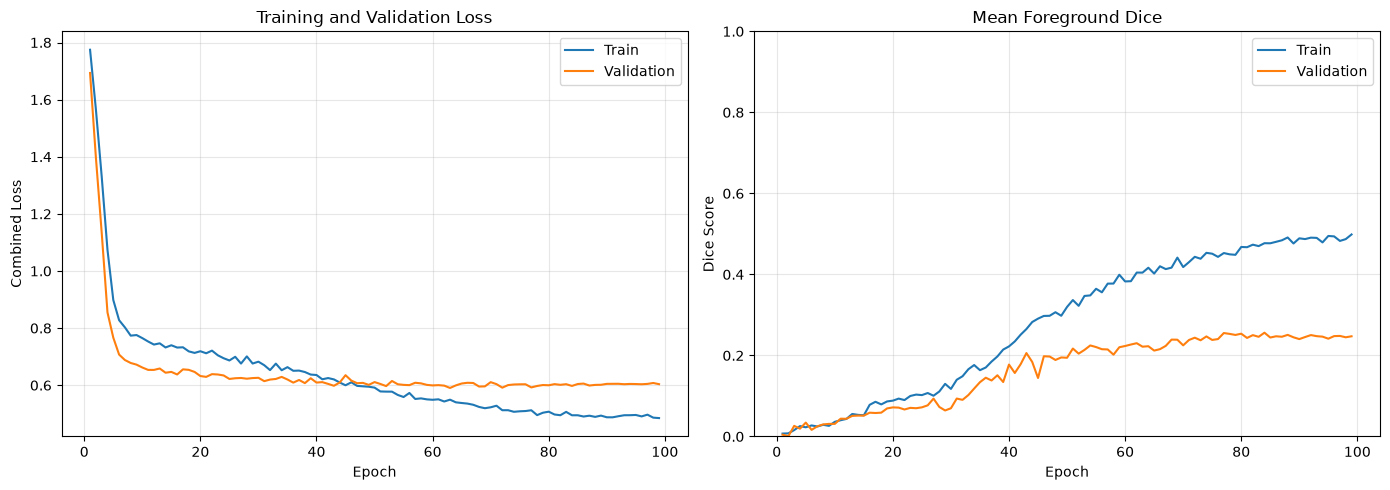

In [77]:
import pandas as pd
import matplotlib.pyplot as plt


history_df = pd.read_csv(history_path)

print("Available history columns:")
print(history_df.columns.tolist())


required_columns = [
    "epoch",
    "train_loss",
    "val_loss",
    "train_mean_foreground_dice",
    "val_mean_foreground_dice",
]

missing_columns = [
    column
    for column in required_columns
    if column not in history_df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns in history file: {missing_columns}\n"
        f"Available columns: {history_df.columns.tolist()}"
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)


# =========================================================
# LOSS CURVES
# =========================================================

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train",
)

axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation",
)

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Combined Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()


# =========================================================
# DICE CURVES
# =========================================================

axes[1].plot(
    history_df["epoch"],
    history_df["train_mean_foreground_dice"],
    label="Train",
)

axes[1].plot(
    history_df["epoch"],
    history_df["val_mean_foreground_dice"],
    label="Validation",
)

axes[1].set_title("Mean Foreground Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.show()

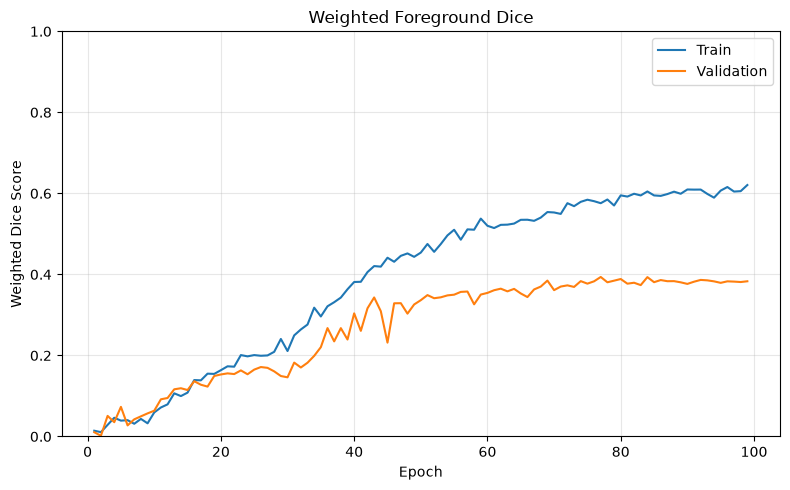

In [78]:

# You can also plot the weighted foreground Dice:
if {
    "train_weighted_foreground_dice",
    "val_weighted_foreground_dice",
}.issubset(history_df.columns):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["train_weighted_foreground_dice"],
        label="Train",
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_weighted_foreground_dice"],
        label="Validation",
    )

    plt.title("Weighted Foreground Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Weighted Dice Score")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 23. Load the best model and evaluate the untouched test set

In [85]:
best_checkpoint = load_checkpoint(
    path=best_path,
    load_optimizer=False,
    strict=True,
)

model.eval()

Loaded checkpoint: /workspace/bash_phd/ml_pipeline/outputs/transunet_stroke/checkpoints/best_transunet.pt
Completed epoch: 83
Best validation Dice: 0.25621835752291766


VisionTransformer(
  (transformer): Transformer(
    (embeddings): Embeddings(
      (hybrid_model): ResNetV2(
        (root): Sequential(
          (conv): StdConv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (gn): GroupNorm(32, 64, eps=1e-06, affine=True, bias=True)
          (relu): ReLU(inplace=True)
        )
        (body): Sequential(
          (block1): Sequential(
            (unit1): PreActBottleneck(
              (gn1): GroupNorm(32, 64, eps=1e-06, affine=True, bias=True)
              (conv1): StdConv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (gn2): GroupNorm(32, 64, eps=1e-06, affine=True, bias=True)
              (conv2): StdConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (gn3): GroupNorm(32, 256, eps=1e-06, affine=True, bias=True)
              (conv3): StdConv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (relu): ReLU(inplace=True)
   

In [86]:
@torch.no_grad()
def evaluate_test_set(
    model: nn.Module,
    loader: DataLoader,
    save_predictions: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    rows = []

    for batch in tqdm(loader, desc="test"):
        images = batch["image"].to(DEVICE, non_blocking=True)
        targets = batch["mask"].to(DEVICE, non_blocking=True)
        sample_ids = batch["sample_id"]

        with autocast(enabled=scaler.is_enabled()):
            logits = model(images)
        predictions = torch.argmax(logits, dim=1)

        for i, sample_id in enumerate(sample_ids):
            pred = predictions[i].cpu().numpy().astype(np.uint8)
            target = targets[i].cpu().numpy().astype(np.uint8)

            tp_i, fp_i, fn_i, tn_i = confusion_counts(
                predictions[i].cpu(),
                targets[i].cpu(),
            )
            metrics = metrics_from_counts(tp_i, fp_i, fn_i, tn_i)
            metrics["hd95"] = hd95_binary(pred == 1, target == 1)
            metrics["sample_id"] = sample_id
            rows.append(metrics)

            if save_predictions:
                Image.fromarray((pred * 255).astype(np.uint8)).save(
                    PREDICTION_DIR / f"{sample_id}_prediction.png"
                )

    per_case = pd.DataFrame(rows)
    aggregate = {}

    for metric in ("dice", "iou", "precision", "recall", "specificity", "accuracy", "hd95"):
        values = per_case[metric].dropna()
        aggregate[f"{metric}_mean"] = float(values.mean())
        aggregate[f"{metric}_std"] = float(values.std(ddof=1)) if len(values) > 1 else 0.0

    return per_case, aggregate


test_per_case, test_summary = evaluate_test_set(model, test_loader)
test_per_case.to_csv(OUTPUT_ROOT / "test_per_case_metrics.csv", index=False)

with (OUTPUT_ROOT / "test_summary.json").open("w") as f:
    json.dump(test_summary, f, indent=2)

pd.DataFrame([test_summary]).T.rename(columns={0: "value"})

test:   0%|          | 0/18 [00:00<?, ?it/s]

/tmp/ipykernel_3063/3789306587.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):
/venv/main/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,value
dice_mean,0.816758
dice_std,0.335837
iou_mean,0.789741
iou_std,0.357322
precision_mean,0.837088
precision_std,0.314787
recall_mean,0.921646
recall_std,0.207516
specificity_mean,0.997355
specificity_std,0.006491


## 24. Bootstrap 95% confidence intervals

In [87]:
def bootstrap_ci(
    values: Sequence[float],
    statistic=np.mean,
    n_bootstrap: int = 5000,
    confidence: float = 0.95,
    seed: int = 42,
) -> Tuple[float, float]:
    clean = np.asarray([v for v in values if np.isfinite(v)], dtype=float)
    if len(clean) == 0:
        return float("nan"), float("nan")

    rng = np.random.default_rng(seed)
    estimates = np.empty(n_bootstrap, dtype=float)
    for i in range(n_bootstrap):
        sample = rng.choice(clean, size=len(clean), replace=True)
        estimates[i] = statistic(sample)

    alpha = (1 - confidence) / 2
    return (
        float(np.quantile(estimates, alpha)),
        float(np.quantile(estimates, 1 - alpha)),
    )


ci_rows = []
for metric in ("dice", "iou", "precision", "recall", "specificity", "hd95"):
    lower, upper = bootstrap_ci(test_per_case[metric].dropna().values, seed=CFG.seed)
    ci_rows.append(
        {
            "metric": metric,
            "mean": test_per_case[metric].mean(),
            "95% CI lower": lower,
            "95% CI upper": upper,
        }
    )

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(OUTPUT_ROOT / "test_confidence_intervals.csv", index=False)
ci_df

,metric,mean,95% CI lower,95% CI upper
0,dice,0.816758,0.761932,0.869692
1,iou,0.789741,0.731887,0.846832
2,precision,0.837088,0.784475,0.886066
3,recall,0.921646,0.886671,0.953300
4,specificity,0.997355,0.996190,0.998321
5,hd95,inf,9.162803,14.817198


## 25. Qualitative test predictions

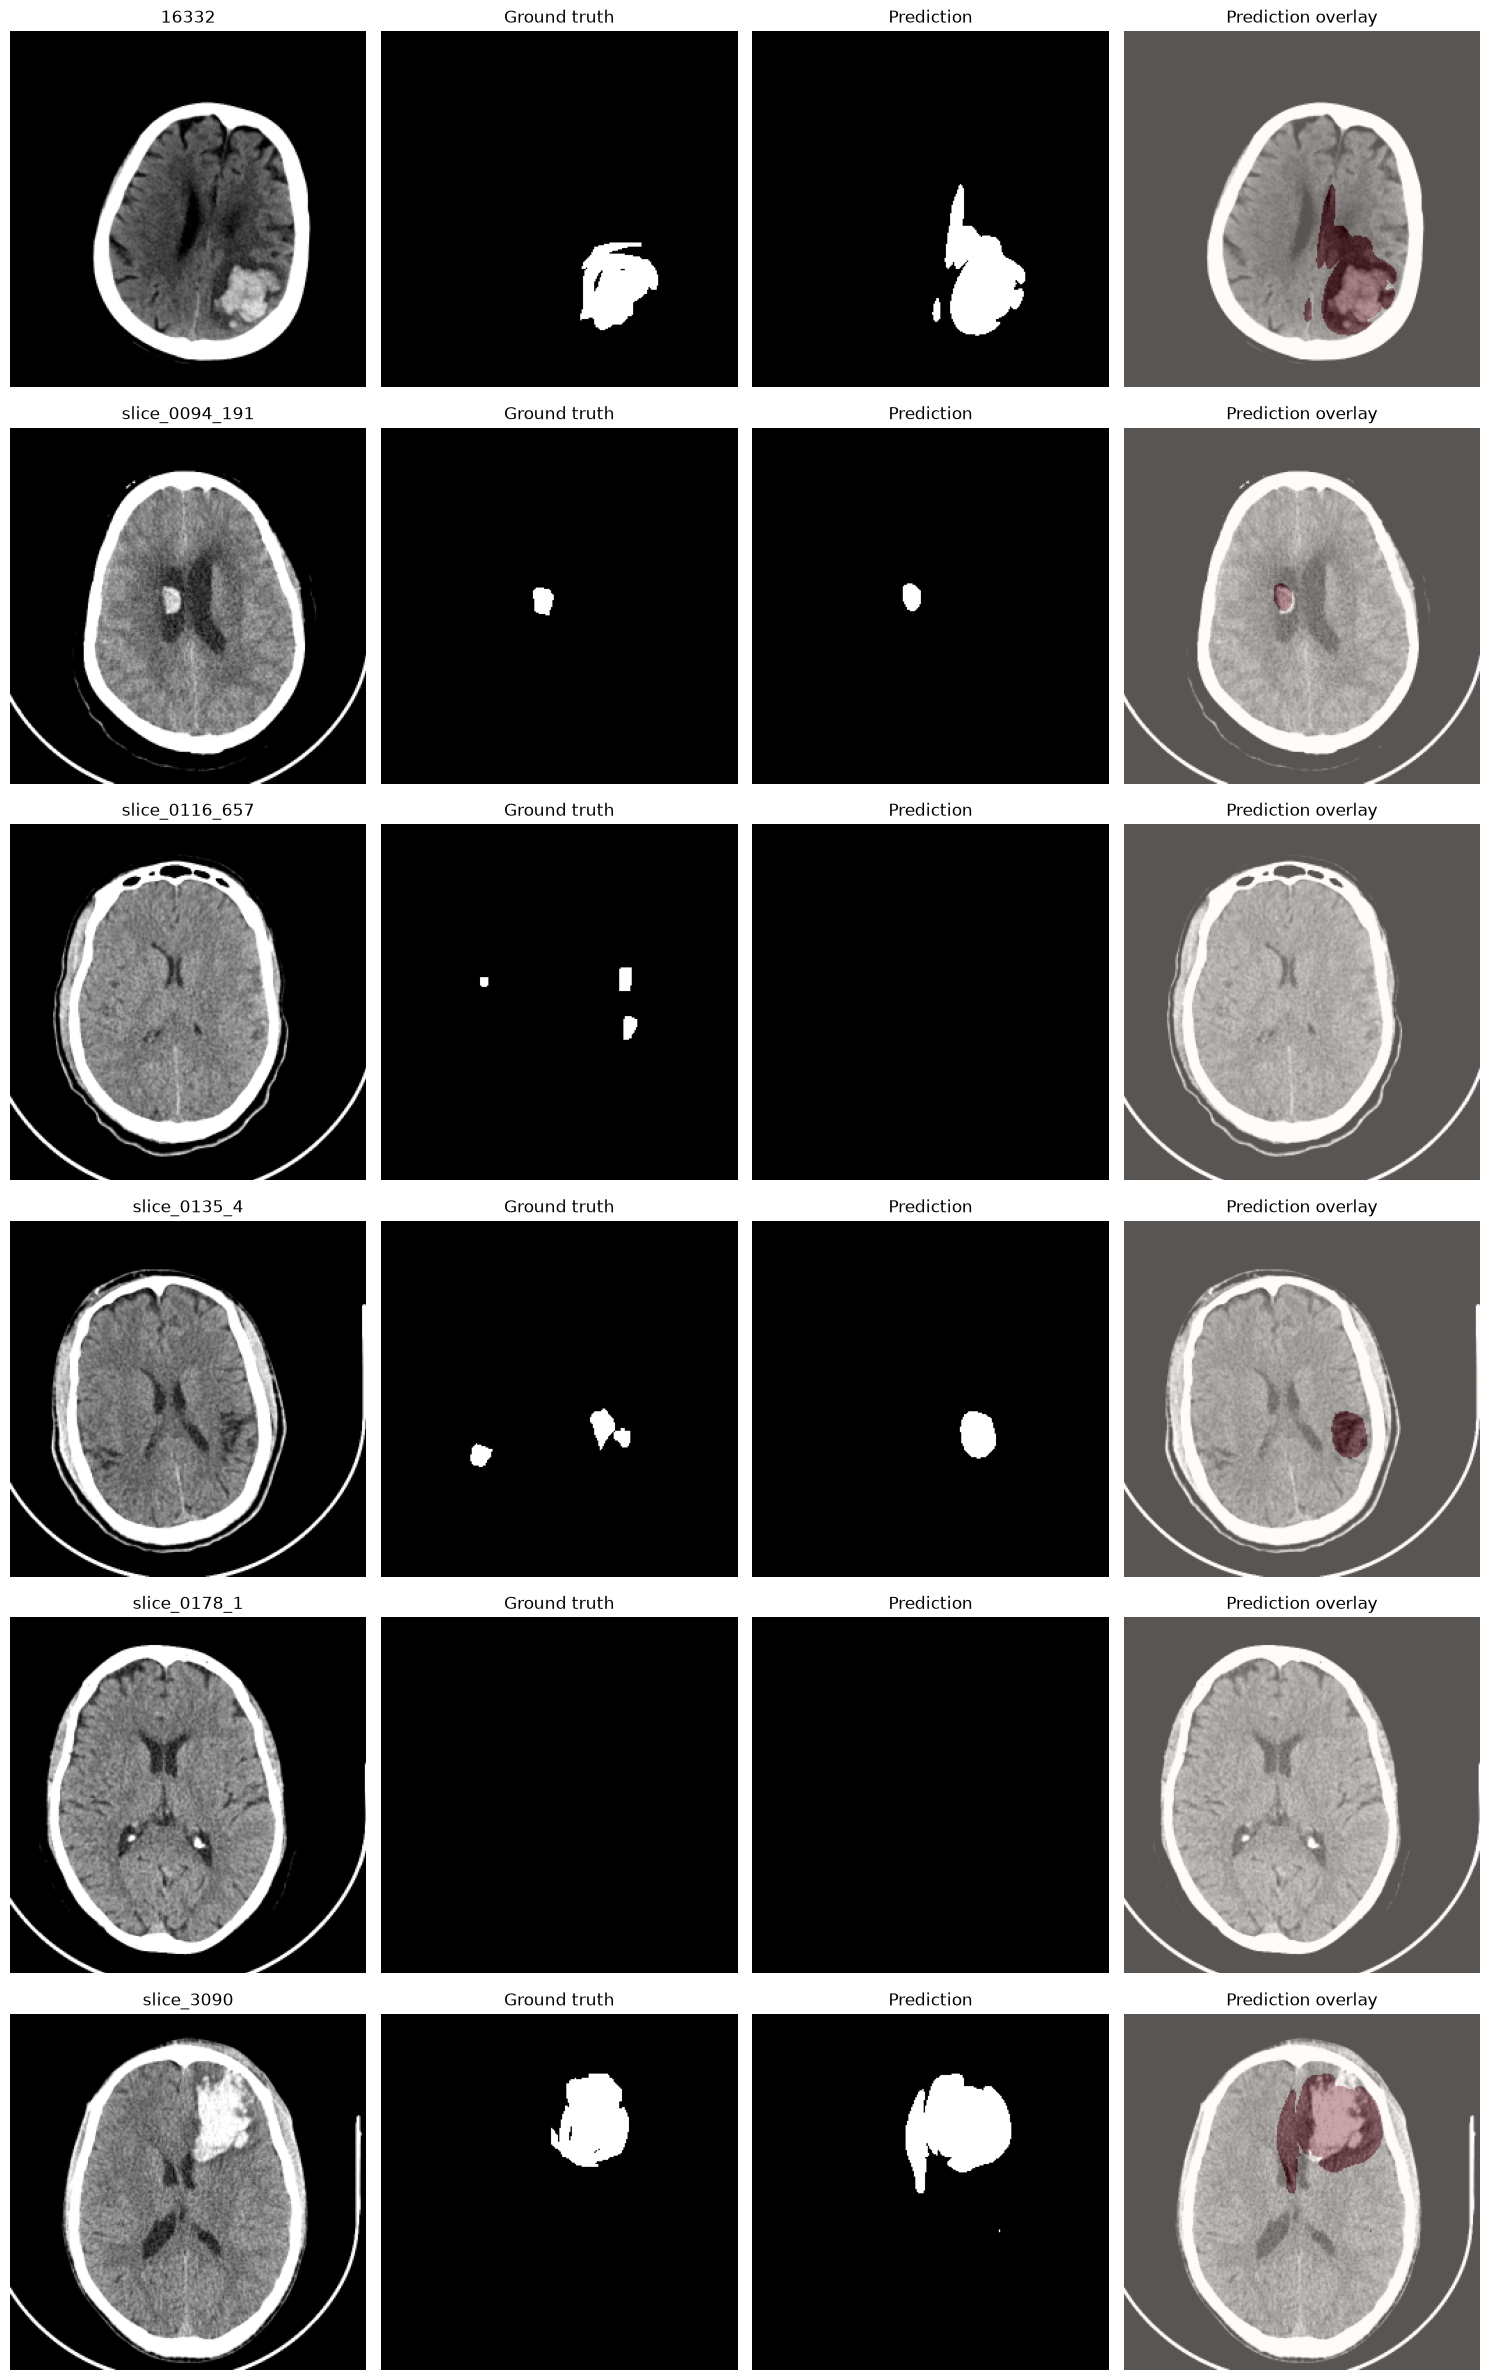

In [88]:
@torch.no_grad()
def visualize_predictions(model: nn.Module, dataset: Dataset, n: int = 6) -> None:
    indices = np.linspace(0, len(dataset) - 1, num=min(n, len(dataset)), dtype=int)
    fig, axes = plt.subplots(len(indices), 4, figsize=(15, 4 * len(indices)))
    axes = np.atleast_2d(axes)

    for row, index in enumerate(indices):
        item = dataset[index]
        image_tensor = item["image"].unsqueeze(0).to(DEVICE)

        logits = model(image_tensor)
        pred = torch.argmax(logits, dim=1)[0].cpu().numpy()
        target = item["mask"].numpy()

        image = item["image"].permute(1, 2, 0).numpy()
        image = np.clip(image * 0.5 + 0.5, 0, 1)

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(item["sample_id"])
        axes[row, 1].imshow(target, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[row, 2].set_title("Prediction")
        axes[row, 3].imshow(image)
        axes[row, 3].imshow(pred, alpha=0.35, cmap="Reds", vmin=0, vmax=1)
        axes[row, 3].set_title("Prediction overlay")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(model, test_dataset)

Loaded checkpoint: /workspace/bash_phd/ml_pipeline/outputs/transunet_stroke/checkpoints/best_transunet.pt
Completed epoch: 83
Best validation Dice: 0.25621835752291766


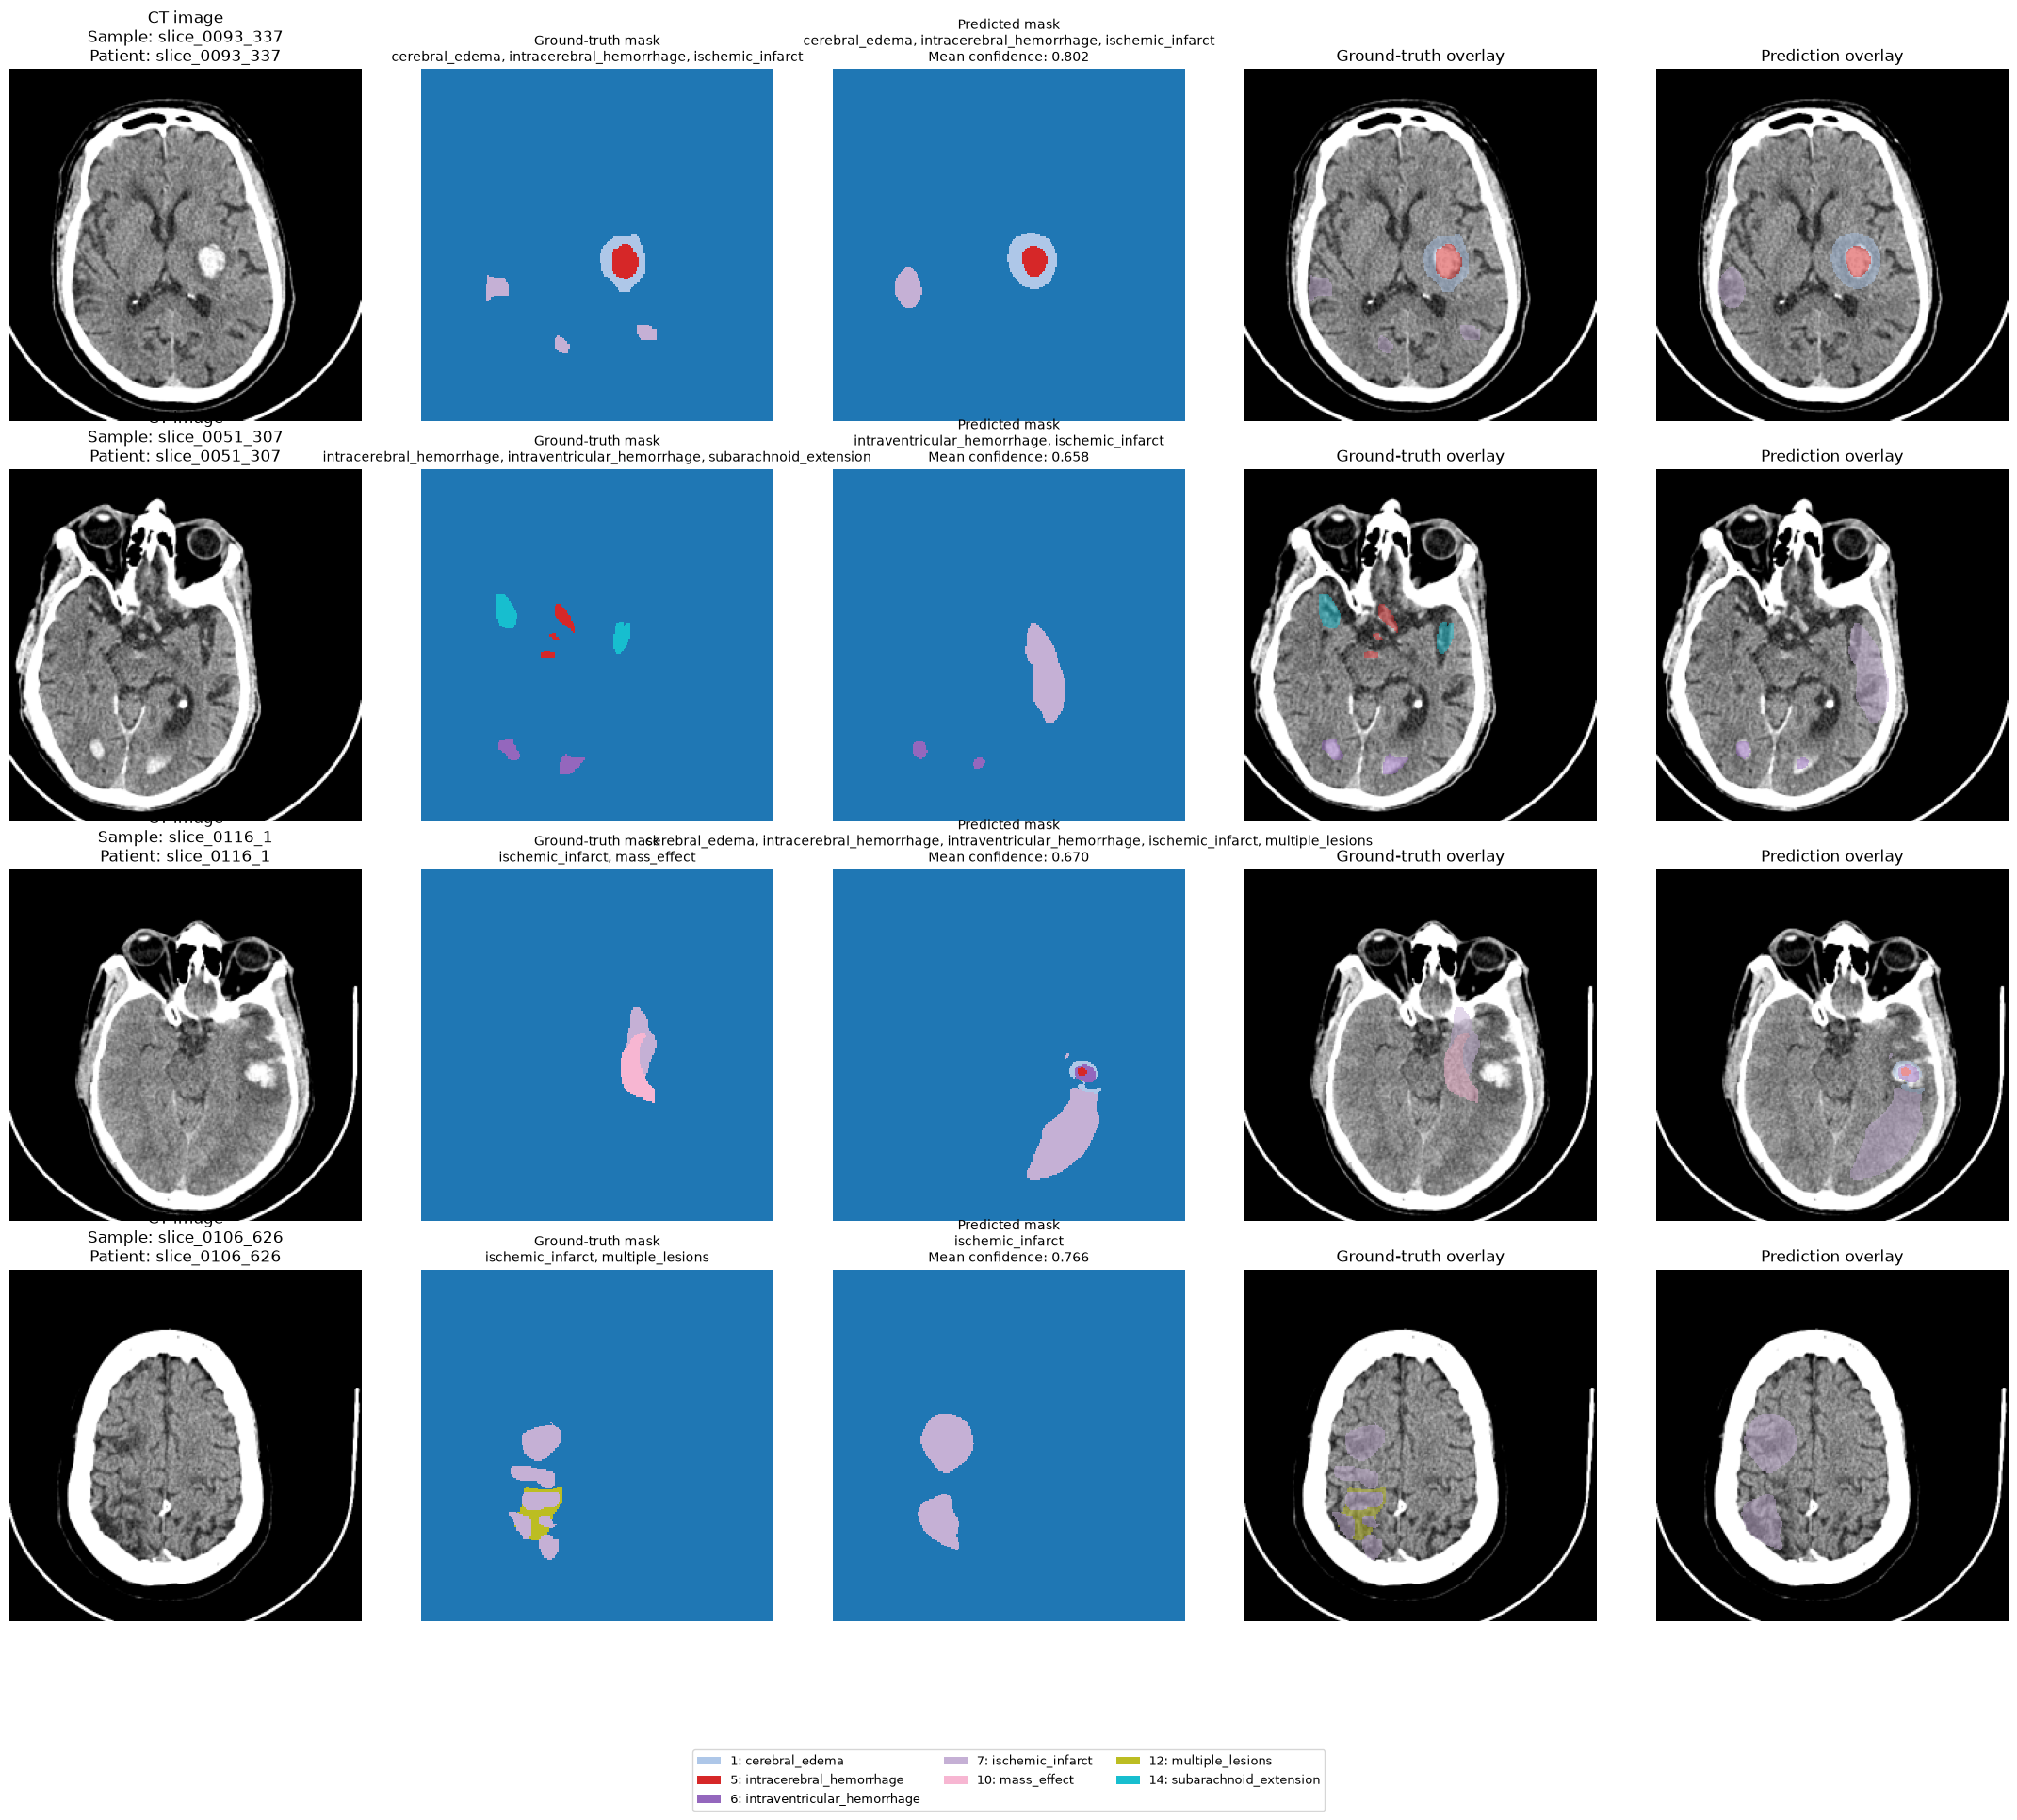

In [89]:
import random
from pathlib import Path
from typing import Dict, Optional, Sequence, Union

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch


# =========================================================
# CLASS NAMES
# =========================================================

CLASS_NAMES = {
    0: "background",
    1: "cerebral_edema",
    2: "cortical_involvement",
    3: "hemorrhagic_transformation",
    4: "hyperdense_artery_sign",
    5: "intracerebral_hemorrhage",
    6: "intraventricular_hemorrhage",
    7: "ischemic_infarct",
    8: "large_lesion_1_3_mca_territory",
    9: "large_vessel_occlusion",
    10: "mass_effect",
    11: "midline_shift",
    12: "multiple_lesions",
    13: "spontaneous_asdh",
    14: "subarachnoid_extension",
    15: "temporal_lobe_involvement",
}

NUM_CLASSES = 16


# =========================================================
# MODEL OUTPUT HELPER
# =========================================================

def extract_logits(model_output):
    """
    Support models returning tensors, dictionaries,
    tuples or lists.
    """

    if isinstance(model_output, torch.Tensor):
        return model_output

    if isinstance(model_output, dict):
        if "out" in model_output:
            return model_output["out"]

        if "logits" in model_output:
            return model_output["logits"]

        raise KeyError(
            "Model output dictionary does not contain "
            "'out' or 'logits'."
        )

    if isinstance(model_output, (tuple, list)):
        if len(model_output) == 0:
            raise ValueError(
                "Model returned an empty tuple or list."
            )

        return model_output[0]

    raise TypeError(
        f"Unsupported model-output type: {type(model_output)}"
    )


# =========================================================
# IMAGE DISPLAY HELPER
# =========================================================

def prepare_image_for_display(
    image_tensor: torch.Tensor,
    mean: float = 0.5,
    std: float = 0.5,
):
    """
    Convert a normalized [C, H, W] tensor into a displayable
    NumPy image.

    This assumes:
        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5)
        )
    """

    image = (
        image_tensor
        .detach()
        .cpu()
        .float()
        .numpy()
    )

    if image.ndim != 3:
        raise ValueError(
            f"Expected image shape [C, H, W], got {image.shape}."
        )

    image = np.transpose(
        image,
        (1, 2, 0),
    )

    # Undo normalization.
    image = image * std + mean
    image = np.clip(image, 0.0, 1.0)

    # TransUNet often receives a grayscale CT image repeated
    # across three channels.
    if (
        image.shape[2] == 1
        or np.allclose(
            image[..., 0],
            image[..., 1],
        )
    ):
        return image[..., 0], "gray"

    return image, None


# =========================================================
# LABEL TEXT HELPER
# =========================================================

def get_class_labels(
    mask: np.ndarray,
    class_names: Dict[int, str],
    ignore_index: Optional[int] = None,
) -> str:
    """
    Return biomarker names present in a mask.
    """

    class_ids = np.unique(mask).astype(int)

    class_ids = [
        class_id
        for class_id in class_ids
        if class_id != 0
        and (
            ignore_index is None
            or class_id != ignore_index
        )
    ]

    if not class_ids:
        return "No foreground biomarker"

    return ", ".join(
        class_names.get(
            class_id,
            f"class_{class_id}",
        )
        for class_id in class_ids
    )


# =========================================================
# MAIN VISUALIZATION FUNCTION
# =========================================================

def show_model_predictions(
    model: torch.nn.Module,
    dataset,
    n: int = 4,
    device: torch.device = DEVICE,
    class_names: Dict[int, str] = CLASS_NAMES,
    num_classes: int = NUM_CLASSES,
    ignore_index: Optional[int] = None,
    random_seed: Optional[int] = None,
) -> None:
    """
    Display CT images, ground-truth biomarker masks and
    predicted masks.

    Use val_dataset or test_dataset rather than train_dataset
    because train_dataset applies random augmentations.
    """

    if len(dataset) == 0:
        print("The dataset contains no samples.")
        return

    if random_seed is not None:
        random.seed(random_seed)

    number_to_show = min(
        n,
        len(dataset),
    )

    selected_indices = random.sample(
        range(len(dataset)),
        k=number_to_show,
    )

    # Discrete colour map for class IDs 0–15.
    mask_cmap = plt.get_cmap(
        "tab20",
        num_classes,
    )

    boundaries = np.arange(
        -0.5,
        num_classes + 0.5,
        1,
    )

    mask_norm = BoundaryNorm(
        boundaries,
        mask_cmap.N,
    )

    figure, axes = plt.subplots(
        number_to_show,
        5,
        figsize=(22, 4.8 * number_to_show),
        squeeze=False,
    )

    model.eval()

    all_classes_displayed = set()

    for row, dataset_index in enumerate(
        selected_indices
    ):
        sample = dataset[dataset_index]

        image_tensor = sample["image"]
        target_tensor = sample["mask"].long()

        sample_id = sample.get(
            "sample_id",
            str(dataset_index),
        )

        patient_id = sample.get(
            "patient_id",
            "unknown",
        )

        model_input = (
            image_tensor
            .unsqueeze(0)
            .to(
                device,
                non_blocking=True,
            )
            .float()
        )

        with torch.no_grad():
            amp_enabled = (
                device.type == "cuda"
                and torch.cuda.is_available()
            )

            with torch.autocast(
                device_type=device.type,
                dtype=(
                    torch.float16
                    if device.type == "cuda"
                    else torch.bfloat16
                ),
                enabled=amp_enabled,
            ):
                model_output = model(
                    model_input
                )

                logits = extract_logits(
                    model_output
                )

                if logits.shape[-2:] != target_tensor.shape[-2:]:
                    logits = F.interpolate(
                        logits,
                        size=target_tensor.shape[-2:],
                        mode="bilinear",
                        align_corners=False,
                    )

            probabilities = torch.softmax(
                logits.float(),
                dim=1,
            )

            confidence_tensor, prediction_tensor = (
                probabilities.max(dim=1)
            )

        prediction = (
            prediction_tensor[0]
            .detach()
            .cpu()
            .numpy()
            .astype(np.int64)
        )

        confidence = (
            confidence_tensor[0]
            .detach()
            .cpu()
            .numpy()
        )

        target = (
            target_tensor
            .detach()
            .cpu()
            .numpy()
            .astype(np.int64)
        )

        display_image, image_cmap = (
            prepare_image_for_display(
                image_tensor
            )
        )

        # Remove ignored pixels from visualization.
        if ignore_index is not None:
            valid_target_mask = (
                target != ignore_index
            )
        else:
            valid_target_mask = np.ones_like(
                target,
                dtype=bool,
            )

        target_for_display = target.copy()

        if ignore_index is not None:
            target_for_display[
                ~valid_target_mask
            ] = 0

        # Hide background pixels in overlays.
        target_overlay = np.ma.masked_where(
            (target_for_display == 0)
            | (~valid_target_mask),
            target_for_display,
        )

        prediction_overlay = np.ma.masked_where(
            prediction == 0,
            prediction,
        )

        ground_truth_classes = set(
            int(class_id)
            for class_id in np.unique(
                target_for_display
            )
            if int(class_id) != 0
        )

        predicted_classes = set(
            int(class_id)
            for class_id in np.unique(
                prediction
            )
            if int(class_id) != 0
        )

        all_classes_displayed.update(
            ground_truth_classes
        )

        all_classes_displayed.update(
            predicted_classes
        )

        ground_truth_labels = get_class_labels(
            target_for_display,
            class_names=class_names,
            ignore_index=ignore_index,
        )

        prediction_labels = get_class_labels(
            prediction,
            class_names=class_names,
        )

        predicted_foreground = prediction > 0

        if predicted_foreground.any():
            mean_foreground_confidence = float(
                confidence[
                    predicted_foreground
                ].mean()
            )
        else:
            mean_foreground_confidence = float(
                confidence.mean()
            )

        # -------------------------------------------------
        # Column 1: CT image
        # -------------------------------------------------
        axes[row, 0].imshow(
            display_image,
            cmap=image_cmap,
        )

        axes[row, 0].set_title(
            f"CT image\n"
            f"Sample: {sample_id}\n"
            f"Patient: {patient_id}"
        )

        # -------------------------------------------------
        # Column 2: Ground truth
        # -------------------------------------------------
        axes[row, 1].imshow(
            target_for_display,
            cmap=mask_cmap,
            norm=mask_norm,
            interpolation="nearest",
        )

        axes[row, 1].set_title(
            "Ground-truth mask\n"
            f"{ground_truth_labels}",
            fontsize=10,
        )

        # -------------------------------------------------
        # Column 3: Prediction
        # -------------------------------------------------
        axes[row, 2].imshow(
            prediction,
            cmap=mask_cmap,
            norm=mask_norm,
            interpolation="nearest",
        )

        axes[row, 2].set_title(
            "Predicted mask\n"
            f"{prediction_labels}\n"
            f"Mean confidence: "
            f"{mean_foreground_confidence:.3f}",
            fontsize=10,
        )

        # -------------------------------------------------
        # Column 4: Ground-truth overlay
        # -------------------------------------------------
        axes[row, 3].imshow(
            display_image,
            cmap=image_cmap,
        )

        axes[row, 3].imshow(
            target_overlay,
            cmap=mask_cmap,
            norm=mask_norm,
            alpha=0.50,
            interpolation="nearest",
        )

        axes[row, 3].set_title(
            "Ground-truth overlay"
        )

        # -------------------------------------------------
        # Column 5: Prediction overlay
        # -------------------------------------------------
        axes[row, 4].imshow(
            display_image,
            cmap=image_cmap,
        )

        axes[row, 4].imshow(
            prediction_overlay,
            cmap=mask_cmap,
            norm=mask_norm,
            alpha=0.50,
            interpolation="nearest",
        )

        axes[row, 4].set_title(
            "Prediction overlay"
        )

        for axis in axes[row]:
            axis.axis("off")

    # =====================================================
    # FIGURE LEGEND
    # =====================================================

    legend_handles = []

    for class_id in sorted(
        all_classes_displayed
    ):
        if class_id <= 0 or class_id >= num_classes:
            continue

        legend_handles.append(
            Patch(
                facecolor=mask_cmap(
                    class_id
                ),
                label=(
                    f"{class_id}: "
                    f"{class_names.get(class_id, f'class_{class_id}')}"
                ),
            )
        )

    if legend_handles:
        figure.legend(
            handles=legend_handles,
            loc="lower center",
            ncol=3,
            bbox_to_anchor=(0.5, 0.0),
            fontsize=9,
        )

        plt.tight_layout(
            rect=(0, 0.10, 1, 1)
        )

    else:
        plt.tight_layout()

    plt.show()


# =========================================================
# LOAD THE BEST CHECKPOINT
# =========================================================

# Use your existing checkpoint loader.
load_checkpoint(
    path=best_path,
    load_optimizer=False,
    strict=True,
)

model.eval()


# =========================================================
# SHOW VALIDATION PREDICTIONS
# =========================================================

show_model_predictions(
    model=model,
    dataset=val_dataset,
    n=4,
    device=DEVICE,
    class_names=CLASS_NAMES,
    num_classes=CFG.num_classes,
    ignore_index=CFG.ignore_index,
    random_seed=42,
)


# To inspect the final held-out test set instead, use:
#
# show_model_predictions(
#     model=model,
#     dataset=test_dataset,
#     n=4,
#     device=DEVICE,
#     class_names=CLASS_NAMES,
#     num_classes=CFG.num_classes,
#     ignore_index=CFG.ignore_index,
#     random_seed=42,
# )

## 26. Export a deployment checkpoint

In [ ]:
deployment_payload = {
    "model_state_dict": model.state_dict(),
    "architecture": {
        "name": "TransUNet",
        "vit_name": CFG.vit_name,
        "image_size": CFG.image_size,
        "vit_patch_size": CFG.vit_patch_size,
        "n_skip": CFG.n_skip,
        "num_classes": CFG.num_classes,
    },
    "preprocessing": {
        "resize": [CFG.image_size, CFG.image_size],
        "input_channels": 3,
        "normalization_mean": [0.5, 0.5, 0.5],
        "normalization_std": [0.5, 0.5, 0.5],
        "mask_class_mapping": {"background": 0, "stroke": 1},
    },
    "validation_best_dice": best_checkpoint["best_val_dice"],
    "test_metrics": test_summary,
}

deployment_path = OUTPUT_ROOT / "transunet_stroke_deployment.pt"
save_checkpoint_atomic(deployment_payload, deployment_path)
print("Saved:", deployment_path)

## 27. Operational checklist

Before reporting this experiment:

- Confirm the split manifest is patient-level where multiple slices belong to one patient.
- Record the exact Git commit used from the official TransUNet repository.
- Keep the test set untouched until model and hyperparameters are finalized.
- Review empty-mask cases separately.
- Inspect false positives and false negatives clinically.
- Report Dice, IoU, precision, recall, specificity, HD95, confidence intervals, parameter count, and inference latency.
- Use the same split manifest, preprocessing, metrics, and reporting code for Models 2 and 3.

In [ ]:
def get_git_commit(repo: Path) -> Optional[str]:
    try:
        return subprocess.check_output(
            ["git", "-C", str(repo), "rev-parse", "HEAD"],
            text=True,
        ).strip()
    except Exception:
        return None

run_metadata = {
    "transunet_git_commit": get_git_commit(REPO_ROOT),
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda,
    "config": asdict(CFG),
}

with (OUTPUT_ROOT / "run_metadata.json").open("w") as f:
    json.dump(run_metadata, f, indent=2)

run_metadata